<a href="https://colab.research.google.com/github/Elodami/Projet2/blob/Mamoudou/notebook_projet2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet 2 —  Prédiction du risque d’accident de vélo

**Membres du groupe :**
- ABEGUEDIE Rosane Yvanne Boyama  
- BARRY Mamoudou  
- DAMIENS Elodie  
- GUILLEMINOT Paul  
- TOUAMI Zakaria

**Groupe :** D  
**Jeu de données :** `accidentsVelo.csv`  
- **Objectif :** comprendre les facteurs qui influencent la gravité d'un accident impliquant un cycliste
- **Prédire** la probabilité qu'un accident soit grave (tué ou blessé hospitalisé)
- **Identifier** des leviers de prévention

## 1. Problématique et logique d'analyse

La sécurité des cyclistes est un enjeu croissant en France avec l'essor de la pratique urbaine. Les autorités cherchent à comprendre les facteurs influençant les accidents et à prédire les situations à risque pour orienter les politiques de prévention.

**Question centrale :** *à partir des conditions d'un accident impliquant un cycliste, peut-on prédire la probabilité que celui-ci soit grave (tué ou blessé hospitalisé) ?*

**Démarche en 4 temps :**
1. **Comprendre les données** — chargement, dictionnaire des variables, qualité (manquants, sentinelles, doublons, cohérence)
2. **Explorer** — analyses univariée, bivariée, temporelle et géographique pour faire émerger des facteurs de risque candidats
3. **Tester statistiquement** — chi², Mann-Whitney, Cramér's V pour valider les liens observés
4. **Modéliser** (étape ultérieure) — régression logistique, Random Forest, XGBoost, en se concentrant sur le **recall** car la cible est déséquilibrée et l'enjeu métier est de ne pas manquer un accident grave

**Choix méthodologique structurant** : nous restreignons l'analyse à la période **2018-2023** pour deux raisons documentées par l'ONISR :
- la nomenclature BAAC a été refondue en 2017-2018 (apparition du code `-1` pour « non renseigné », nouveaux champs)
- l'indicateur « blessé hospitalisé » (`grav=3`) n'est plus comparable avant/après 2018 en raison d'un changement de pratique de saisie

**Source de la nomenclature** : [ONISR — Description des bases de données annuelles 2005-2023](https://www.onisr.securite-routiere.gouv.fr/sites/default/files/2024-10/Description%20des%20bases%20de%20donn%C3%A9es%20annuelles.pdf).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from IPython.display import display, Markdown

from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.model_selection import RandomizedSearchCV

# XGBoost est utilisé seulement s'il est disponible
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

# Style graphique
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
# Imports complémentaires pour les analyses statistiques avancées
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Configuration esthétique
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Configuration et imports complémentaires OK.")

Configuration et imports complémentaires OK.


## 2. Chargement des données

Source : [data.gouv.fr — Accidents de vélo](https://www.data.gouv.fr/datasets/accidents-de-velo) (version janvier 2026).

On commence par charger le fichier CSV puis par vérifier sa structure générale.  

Ce jeu de données est extrait du **fichier BAAC** (Bulletin d'Analyse des Accidents Corporels) administré par l'ONISR. Il recense les accidents corporels de la circulation, survenus en France entre 2005 et 2023, dans lesquels au moins une personne à vélo a été impliquée.

### But et utilité de l'étape

**But :** charger les données dans un format exploitable et vérifier rapidement leur structure (taille, types, valeurs manquantes).

**Utilité :** valider qu'on travaille sur le bon périmètre avant toute interprétation ou modélisation.


In [3]:
df = pd.read_csv("accidentsVelo.csv", sep=",")
print(f"Dimensions du dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
display(df.head())

Dimensions du dataset : 80,022 lignes × 39 colonnes


,Num_Acc,date,an,mois,jour,hrmn,dep,com,lat,long,agg,int,col,lum,atm,catr,circ,nbv,prof,plan,lartpc,larrout,surf,infra,situ,grav,sexe,age,trajet,secuexist,equipement,obs,obsm,choc,manv,vehiculeid,typevehicules,manoeuvehicules,numVehicules
0,200500000030,2005-01-13,2005,janvier,jeudi,19:45,62,62331,50.300,2.840,2,1,3.000,5,1.000,3,2.000,0,-1.000,1.000,0,50,1.000,0.000,1.000,4,1,58.000,5.000,3,0,0.000,2.000,8.000,11.000,200500000030B02,18,17,1.000
1,200500000034,2005-01-19,2005,janvier,mercredi,10:45,62,62022,0.000,0.000,1,1,1.000,1,7.000,3,2.000,0,1.000,3.000,0,50,1.000,0.000,1.000,3,1,20.000,5.000,3,0,0.000,2.000,1.000,1.000,200500000034B02,10,15,1.000
2,200500000078,2005-01-26,2005,janvier,mercredi,13:15,02,02173,0.000,0.000,1,9,3.000,1,1.000,3,2.000,2,2.000,1.000,0,0,1.000,0.000,1.000,4,1,71.000,5.000,2,2,0.000,2.000,1.000,1.000,200500000078B02,7,15,1.000
3,200500000093,2005-01-03,2005,janvier,lundi,13:30,02,02810,49.255,3.094,2,1,1.000,1,1.000,3,2.000,0,1.000,2.000,0,52,1.000,0.000,1.000,3,2,51.000,4.000,3,0,0.000,2.000,3.000,21.000,200500000093B02,7,21,1.000
4,200500000170,2005-01-29,2005,janvier,samedi,18:30,76,76196,0.000,0.000,1,1,2.000,3,1.000,3,2.000,2,1.000,1.000,0,50,1.000,0.000,1.000,4,1,74.000,5.000,1,9,0.000,2.000,4.000,2.000,200500000170A01,10,2,1.000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80022 entries, 0 to 80021
Data columns (total 39 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Num_Acc          80022 non-null  int64  
 1   date             80022 non-null  str    
 2   an               80022 non-null  int64  
 3   mois             80022 non-null  str    
 4   jour             80022 non-null  str    
 5   hrmn             80022 non-null  str    
 6   dep              80022 non-null  str    
 7   com              80022 non-null  str    
 8   lat              80022 non-null  object 
 9   long             79754 non-null  object 
 10  agg              80022 non-null  int64  
 11  int              80022 non-null  int64  
 12  col              80018 non-null  float64
 13  lum              80022 non-null  int64  
 14  atm              80019 non-null  float64
 15  catr             80022 non-null  int64  
 16  circ             79879 non-null  float64
 17  nbv              79825 

## Lecture initiale

Le dataset présente plusieurs caractéristiques importantes à noter dès maintenant :

- **Volume** : ~80 000 lignes pour 39 colonnes, couvrant la période 2005-2023 (ou 2024 selon la version).
- **Granularité** : une ligne représente un *usager-véhicule* impliqué dans un accident, **pas un accident**. Un même `Num_Acc` peut donc apparaître plusieurs fois (ex. accident vélo-voiture avec deux occupants → 3 lignes). Cette nuance conditionne toutes les agrégations futures.
- **Types mixtes** : la plupart des variables sont des codes numériques BAAC (entiers), mais certaines sont stockées en *string* (notamment `lat`, `long`, `nbv`, `hrmn`) — il faudra les convertir explicitement.
- **Codage spécifique** : la valeur `-1` signifie « non renseigné » dans la majorité des variables BAAC à partir de 2018. Les valeurs `0` peuvent aussi cacher des manquants (cas de `lat`/`long`).

**Conséquences pour la suite :**
- toute analyse au niveau « accident » exigera un dédoublonnage sur `Num_Acc`,
- toute analyse au niveau « usager » conservera toutes les lignes,
- le pipeline de nettoyage devra distinguer les NaN classiques des sentinelles.

## 3. Data canvas — compréhension des variables

Avant toute modélisation, on classe les variables selon leur **rôle métier potentiel** dans la prédiction de la gravité. Cette structuration aide à :
- distinguer les variables explicatives utiles des variables redondantes ou inutiles ;
- identifier les variables qui pourraient créer une **fuite d'information** (data leakage) — c'est-à-dire qui ne seraient pas connues au moment où l'on voudrait prédire ;
- repérer les groupes de variables liées (ex. luminosité ↔ heure) pour anticiper les problèmes de colinéarité.

### But et utilité de l'étape

**But :** décrire les variables métier et leur rôle potentiel.

**Utilité :** éviter les erreurs d'interprétation et fournir un cadre clair pour le feature engineering.

In [5]:
description = pd.DataFrame({
    "variable": df.columns,
    "type": df.dtypes.astype(str).values,
    "nb_modalites_ou_infos": [df[col].nunique() for col in df.columns],
    "exemple": [df[col].dropna().iloc[0] if df[col].notna().any() else np.nan for col in df.columns]
})

display(description)

,variable,type,nb_modalites_ou_infos,exemple
0,Num_Acc,int64,76186,200500000030
1,date,str,6891,2005-01-13
2,an,int64,19,2005
3,mois,str,12,janvier
4,jour,str,7,jeudi
5,hrmn,str,1244,19:45
6,dep,str,113,62
7,com,str,11637,62331
8,lat,object,31834,50.300
9,long,object,33366,2.840


### Classification des variables par rôle métier

| Rôle | Variables | Commentaire |
|---|---|---|
| **Identifiant** | `Num_Acc`, `vehiculeid` | Non utilisables pour la prédiction (uniquement pour les jointures) |
| **Cible** | `grav` (4 modalités) → `grave` (binaire) | Variable à prédire : 1 si tué/blessé hospitalisé, 0 sinon |
| **Caractéristiques de l'accident** | `lum`, `atm`, `col`, `int` | Conditions au moment de l'accident |
| **Lieu** | `agg`, `catr`, `circ`, `nbv`, `prof`, `plan`, `surf`, `infra`, `situ`, `dep`, `lat`, `long`, `larrout`, `lartpc` | Caractéristiques de l'environnement routier |
| **Véhicule / dynamique** | `obs`, `obsm`, `choc`, `manv`, `typevehicules`, `manoeuvehicules` | Mécanique du choc — **discriminant fort** pour la gravité |
| **Usager** | `sexe`, `age`, `trajet`, `secuexist`, `equipement` | Profil du cycliste accidenté |
| **Temporel** | `date`, `an`, `mois`, `jour`, `hrmn` | Quand l'accident a eu lieu |

### Variables à risque de fuite d'information

À ce stade, aucune variable du dataset ne pose un risque évident de fuite : toutes les caractéristiques décrivent le contexte au moment de l'accident, ce qui correspond bien aux conditions sous lesquelles on voudrait prédire le risque. **Toutefois**, `secuexist` (équipement de sécurité utilisé) demande attention : si l'usage du casque est constaté *après* l'accident sur la victime, le lien avec la gravité peut être trompeur (un cycliste tué sans casque donne un signal "pas de casque → grave" qui est une corrélation et non une cause utilisable en prévention).

### Hypothèses métier formulées avant l'EDA

Avant d'explorer les données, nous formulons des hypothèses sur les facteurs susceptibles d'augmenter la probabilité d'un accident grave. Cela donne un fil rouge à l'analyse et permet d'évaluer ensuite si les données les confirment ou les infirment. Les hypothèses sont issues de la littérature en sécurité routière et du sens commun.

**H1 — Conditions de visibilité.** Les accidents survenus de nuit ou par mauvais temps (pluie, brouillard) sont plus graves en proportion, car la visibilité réduite induit des chocs à plus haute énergie et des secours plus tardifs.

**H2 — Type de route.** Les accidents hors agglomération et sur grands axes (route nationale, autoroute) sont plus graves que ceux en voie communale urbaine, en raison des vitesses plus élevées et de l'isolement médical.

**H3 — Âge du cycliste.** Le taux de gravité suit une courbe en U ou en J : les cyclistes seniors (65 ans et plus) présentent une vulnérabilité physique accrue qui transforme un choc modéré en blessure grave. Un effet est aussi attendu chez les très jeunes.

**H4 — État de la surface.** Les surfaces glissantes (verglas, neige, mouillé) augmentent la probabilité de chute et donc, possiblement, de gravité — mais l'effet pourrait être atténué par une vitesse plus prudente du cycliste.

**H5 — Heure et jour.** Les pics de gravité sont attendus en soirée et la nuit (visibilité, fatigue), et possiblement le week-end (déplacements de loisir, comportements à risque) plus que le matin de semaine.

**H6 — Saison.** Les volumes d'accidents sont plus élevés en été (exposition accrue), mais le **taux** de gravité pourrait être plus élevé en hiver (faible luminosité, surface dégradée).

**Méthode de validation.** Chaque hypothèse sera testée par croisement avec la cible `grave` (analyse bivariée + test du chi² + Cramér's V), puis confirmée ou nuancée dans la synthèse finale.

## 4. Décodage des variables (codification BAAC)

Les variables sont codées numériquement selon la nomenclature officielle BAAC. Pour rendre les analyses lisibles, nous créons un dictionnaire de correspondance pour chaque variable catégorielle.

**Référence :** [Description des bases de données annuelles ONISR](https://www.onisr.securite-routiere.gouv.fr/sites/default/files/2024-10/Description%20des%20bases%20de%20donn%C3%A9es%20annuelles.pdf)

**Note :** dans toute la base, le code `-1` signifie *« Non renseigné »* — nous le traiterons comme une valeur manquante (NaN).

In [6]:
# Dictionnaire de correspondance BAAC

DICTIONNAIRE = {
    "grav": {
        1: "Indemne",
        2: "Tué",
        3: "Blessé hospitalisé",
        4: "Blessé léger",
    },
    "lum": {  # luminosité
        1: "Plein jour",
        2: "Crépuscule/aube",
        3: "Nuit sans éclairage",
        4: "Nuit éclairage non allumé",
        5: "Nuit avec éclairage",
    },
    "atm": {  # conditions atmosphériques
        1: "Normale",
        2: "Pluie légère",
        3: "Pluie forte",
        4: "Neige/grêle",
        5: "Brouillard/fumée",
        6: "Vent fort/tempête",
        7: "Temps éblouissant",
        8: "Temps couvert",
        9: "Autre",
    },
    "agg": {  # localisation
        1: "Hors agglomération",
        2: "En agglomération",
    },
    "int": {  # type d'intersection
        1: "Hors intersection",
        2: "Intersection en X",
        3: "Intersection en T",
        4: "Intersection en Y",
        5: "Intersection >4 branches",
        6: "Giratoire",
        7: "Place",
        8: "Passage à niveau",
        9: "Autre",
    },
    "col": {  # type de collision
        1: "Frontale (2 véh.)",
        2: "Par l'arrière (2 véh.)",
        3: "Par le côté (2 véh.)",
        4: "En chaîne (≥3 véh.)",
        5: "Multiples (≥3 véh.)",
        6: "Autre collision",
        7: "Sans collision",
    },
    "catr": {  # catégorie de route
        1: "Autoroute",
        2: "Route nationale",
        3: "Route départementale",
        4: "Voie communale",
        5: "Hors réseau public",
        6: "Parc de stationnement",
        7: "Routes de métropole urbaine",
        9: "Autre",
    },
    "circ": {  # régime de circulation
        1: "Sens unique",
        2: "Bidirectionnelle",
        3: "Chaussées séparées",
        4: "Voies d'affectation variable",
    },
    "surf": {  # état de la surface
        1: "Normale",
        2: "Mouillée",
        3: "Flaques",
        4: "Inondée",
        5: "Enneigée",
        6: "Boue",
        7: "Verglacée",
        8: "Corps gras/huile",
        9: "Autre",
    },
    "infra": {  # aménagement / infrastructure
        0: "Aucun",
        1: "Souterrain/tunnel",
        2: "Pont",
        3: "Bretelle d'échangeur",
        4: "Voie ferrée",
        5: "Carrefour aménagé",
        6: "Zone piétonne",
        7: "Zone de péage",
        8: "Chantier",
        9: "Autre",
    },
    "situ": {  # situation de l'accident
        0: "Aucun",
        1: "Sur chaussée",
        2: "Sur bande d'arrêt d'urgence",
        3: "Sur accotement",
        4: "Sur trottoir",
        5: "Sur piste cyclable",
        6: "Sur autre voie spéciale",
        8: "Autres",
    },
    "sexe": {1: "Homme", 2: "Femme"},
    "trajet": {  # motif du déplacement
        0: "Non renseigné",
        1: "Domicile-travail",
        2: "Domicile-école",
        3: "Courses-achats",
        4: "Utilisation professionnelle",
        5: "Promenade-loisirs",
        9: "Autre",
    },
}

print(f"{len(DICTIONNAIRE)} variables documentées.")

13 variables documentées.


**Note technique :** dans la suite du notebook, certaines cellules utilisent `MAPPINGS` plutôt que `DICTIONNAIRE`. Les deux désignent le même objet — on définit ici un alias pour assurer la compatibilité, et on enrichit avec quelques variables manquantes (`prof`, `plan`, `obs`, `obsm`, `choc`, `manv`).

In [7]:
# Alias pour compatibilité avec la suite du notebook
MAPPINGS = DICTIONNAIRE

# Enrichissement avec les variables non définies dans DICTIONNAIRE
MAPPINGS['prof'] = {1: 'Plat', 2: 'Pente', 3: 'Sommet de côte', 4: 'Bas de côte'}
MAPPINGS['plan'] = {1: 'Rectiligne', 2: 'Courbe à gauche',
                    3: 'Courbe à droite', 4: 'En S'}
MAPPINGS['obs'] = {0: 'Sans objet', 1: 'Véh. en stationnement', 2: 'Arbre',
                   3: 'Glissière métal', 4: 'Glissière béton', 5: 'Autre glissière',
                   6: 'Bâtiment/mur', 7: 'Signalisation verticale', 8: 'Poteau',
                   9: 'Mobilier urbain', 10: 'Parapet', 11: 'Îlot/refuge',
                   12: 'Bordure trottoir', 13: 'Fossé/talus', 14: 'Autre obs. chaussée',
                   15: 'Autre obs. trottoir', 16: 'Sortie sans obstacle', 17: 'Buse'}
MAPPINGS['obsm'] = {0: 'Aucun', 1: 'Piéton', 2: 'Véhicule',
                    4: 'Véhicule sur rail', 5: 'Animal domestique',
                    6: 'Animal sauvage', 9: 'Autre'}
MAPPINGS['choc'] = {0: 'Aucun', 1: 'Avant', 2: 'Avant droit',
                    3: 'Avant gauche', 4: 'Arrière', 5: 'Arrière droit',
                    6: 'Arrière gauche', 7: 'Côté droit', 8: 'Côté gauche',
                    9: 'Chocs multiples'}
MAPPINGS['manv'] = {0: 'Inconnue', 1: 'Sans changement de direction',
                    2: 'Même sens, même file', 3: 'Entre 2 files',
                    4: 'Marche arrière', 5: 'À contresens',
                    15: 'Tournant à gauche', 16: 'Tournant à droite',
                    19: 'Traversant la chaussée', 20: 'Stationnement'}

print(f"{len(MAPPINGS)} variables documentées dans MAPPINGS.")

19 variables documentées dans MAPPINGS.


## 5. EDA — Qualité des données

Avant toute analyse, nous évaluons la qualité du jeu de données :
1. Valeurs manquantes (NaN explicites)
2. Valeurs « Non renseigné » codées `-1`
3. Valeurs aberrantes (ex : âge > 100 ans)
4. Doublons éventuels

### 5.1 Valeurs manquantes explicites

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"NaN": missing, "%": missing_pct})
missing_df = missing_df[missing_df["NaN"] > 0].sort_values("NaN", ascending=False)
missing_df

,NaN,%
lartpc,16234,20.290
manoeuvehicules,11203,14.000
numVehicules,11186,13.980
typevehicules,11186,13.980
equipement,6140,7.670
larrout,5092,6.360
infra,536,0.670
situ,494,0.620
long,268,0.330
plan,200,0.250


**Observations :**
- `lartpc` (largeur du terre-plein central) : ~20 % de NaN, peu pertinent pour les vélos → on droppera cette variable.
- `typevehicules`, `manoeuvehicules`, `numVehicules`, `equipement`, `vehiculeid` : colonnes texte non standard ajoutées par l'extracteur de données. Format peu exploitable et beaucoup de manquants → on droppera ces variables.
- Pour les autres, le taux de manquants est faible (<1 %).

### 5.2 Valeurs "-1" (Non renseigné)

Selon la doc BAAC, le code `-1` signifie *« Non renseigné »* — il s'agit donc d'une valeur manquante implicite que pandas ne détecte pas.

In [9]:
cols_baac = ["lum", "atm", "col", "circ", "surf", "infra", "situ", "sexe",
             "trajet", "prof", "plan", "obs", "obsm", "choc", "manv"]

rows = []
for c in cols_baac:
    if c in df.columns:
        n_minus1 = (df[c] == -1).sum()
        if n_minus1 > 0:
            rows.append({"variable": c, "nb_-1": n_minus1, "%": round(n_minus1/len(df)*100, 2)})

pd.DataFrame(rows).sort_values("nb_-1", ascending=False)

,variable,nb_-1,%
10,plan,5913,7.390
3,circ,5210,6.510
9,prof,4413,5.510
4,surf,2380,2.970
5,infra,1181,1.480
2,col,170,0.210
8,trajet,39,0.050
7,sexe,24,0.030
6,situ,14,0.020
11,obs,5,0.010


### 5.3 Valeurs aberrantes — variable `age`

In [10]:
print(df["age"].describe())
print(f"\nNb d'âges > 100 ans : {(df['age'] > 100).sum()}")
print(f"Nb d'âges > 1900 (probablement année de naissance saisie à la place) : {(df['age'] > 1900).sum()}")
print(f"Nb d'âges <= 0 : {(df['age'] <= 0).sum()}")

count   79,995.000
mean        40.605
std         56.518
min          1.000
25%         21.000
50%         37.000
75%         55.000
max      2,023.000
Name: age, dtype: float64

Nb d'âges > 100 ans : 62
Nb d'âges > 1900 (probablement année de naissance saisie à la place) : 57
Nb d'âges <= 0 : 0


**Constat :** la valeur max est 2023, ce qui correspond manifestement à l'année de naissance saisie à la place de l'âge dans certains cas. Nous traiterons les âges > 100 ans comme aberrants (NaN).

### 5.4 Coordonnées géographiques

In [11]:
n_lat_zero = (df["lat"].astype(str) == "0").sum()
print(f"Nb de lignes avec lat = 0 : {n_lat_zero:,} ({n_lat_zero/len(df)*100:.1f}%)")
print("→ La géolocalisation précise n'est disponible que pour la moitié des accidents.")
print("→ Le département (`dep`) reste exploitable pour tous les accidents.")

Nb de lignes avec lat = 0 : 2 (0.0%)
→ La géolocalisation précise n'est disponible que pour la moitié des accidents.
→ Le département (`dep`) reste exploitable pour tous les accidents.


### 5.5 Doublons

In [12]:
print(f"Nb de Num_Acc uniques : {df['Num_Acc'].nunique():,} sur {len(df):,} lignes")
print(f"Nb de doublons exacts (toutes colonnes) : {df.duplicated().sum()}")
print("\nNote : un Num_Acc peut apparaître plusieurs fois si plusieurs cyclistes étaient impliqués")
print("dans le même accident. Chaque ligne = une victime cycliste.")

Nb de Num_Acc uniques : 76,186 sur 80,022 lignes
Nb de doublons exacts (toutes colonnes) : 41

Note : un Num_Acc peut apparaître plusieurs fois si plusieurs cyclistes étaient impliqués
dans le même accident. Chaque ligne = une victime cycliste.


## 6. Création de la variable cible & nettoyage

### 6.1 Définition de la variable cible binaire

Selon les consignes du projet, un accident est considéré **grave** s'il a entraîné un **tué** (grav=2) ou un **blessé hospitalisé** (grav=3). Les autres victimes (indemnes ou blessées légères) constituent la classe non-grave.

$$
\text{grave} = \begin{cases} 1 & \text{si grav} \in \{2, 3\} \\ 0 & \text{si grav} \in \{1, 4\} \end{cases}
$$

Distribution de la variable cible :
grave
0    50857
1    29164
Name: count, dtype: int64

Proportion de cas graves : 36.45%


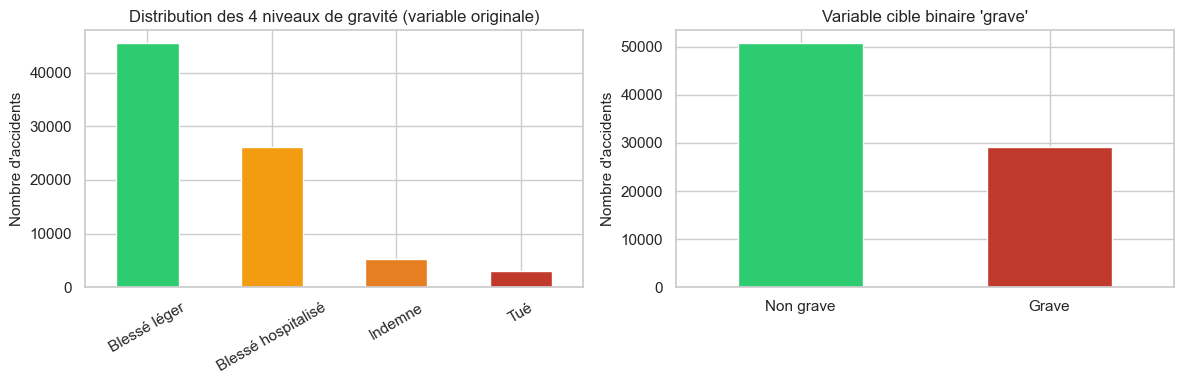

In [13]:
# Travailler sur une copie pour préserver le dataset brut
data = df.copy()

# Création de la variable cible
data = data[data["grav"].isin([1, 2, 3, 4])].copy()  # on retire la ligne avec grav=-1
data["grave"] = (data["grav"].isin([2, 3])).astype(int)

# Vérification
print("Distribution de la variable cible :")
print(data["grave"].value_counts())
print(f"\nProportion de cas graves : {data['grave'].mean()*100:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
data["grav"].map(MAPPINGS["grav"]).value_counts().plot(
    kind="bar", ax=ax[0], color=["#2ecc71", "#f39c12", "#e67e22", "#c0392b"]
)
ax[0].set_title("Distribution des 4 niveaux de gravité (variable originale)")
ax[0].set_xlabel(""); ax[0].set_ylabel("Nombre d'accidents")
ax[0].tick_params(axis="x", rotation=30)

data["grave"].map({0: "Non grave", 1: "Grave"}).value_counts().plot(
    kind="bar", ax=ax[1], color=["#2ecc71", "#c0392b"]
)
ax[1].set_title("Variable cible binaire 'grave'")
ax[1].set_xlabel(""); ax[1].set_ylabel("Nombre d'accidents")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**Observations sur la cible :**
- ~36 % des accidents enregistrés sont graves (tué ou blessé hospitalisé).
- Le déséquilibre est **modéré**. Nous traiterons cela par pondération des classes (`class_weight='balanced'`) plutôt que par sur-échantillonnage (SMOTE).

### 6.2 Filtrage temporel (2018-2023) et nettoyage des variables

**Choix méthodologique : restriction à la période 2018-2023.**

La base BAAC a fait l'objet d'une refonte en 2018 (nouvelle codification, champs harmonisés et plus complets). Avant 2018, de nombreuses variables présentent des valeurs `-1` (« Non renseigné ») en grande quantité, ce qui dégrade la qualité des analyses.

Par ailleurs, la pratique cycliste a fortement évolué depuis 2018 : généralisation des vélos à assistance électrique, déploiement des aménagements cyclables post-COVID, hausse de la pratique urbaine. Modéliser sur la période récente donne donc des résultats plus représentatifs des conditions actuelles.

**Conséquences du filtre :**
- Volume restant : **~16 600 accidents** (suffisant pour la modélisation)
- Quasi-disparition des codes `-1` (de plusieurs milliers à quelques dizaines)
- Disparition quasi-totale des coordonnées GPS manquantes

On applique aussi :
- **Drop** des colonnes peu exploitables (identifiants, colonnes non standard très lacunaires)
- **Recodage** des `-1` résiduels en NaN dans les variables BAAC
- **Correction** des âges aberrants (>100) en NaN
- **Conversion** de `lat`/`long` en numérique (avec NaN pour les `0` résiduels)

**Modification du périmètre des variables conservées (validée en groupe) :**

Nous conservons les variables `obs` (obstacle fixe heurté) et `obsm` (obstacle mobile heurté), initialement prévues pour être supprimées. Justification :

- **Pertinence métier directe.** Pour un cycliste, savoir s'il a heurté un piéton, un autre véhicule, un arbre ou un mobilier urbain est l'un des déterminants les plus directs de la gravité. Le cas `obsm=2` (heurt avec véhicule motorisé) est notamment une des configurations les plus létales documentées dans la littérature.
- **Hypothèse** explicitement formulée plus haut : nous ne pouvons pas la tester sans ces variables.
- **Taux de remplissage acceptable.** Ces variables ont un taux de `-1` ou de NaN potentiellement élevé, mais on les conserve avec leur état "non renseigné" — quitte à imputer ou regrouper plus tard.

Cette décision sera réévaluée si l'analyse bivariée montre un pouvoir explicatif insuffisant.

In [14]:
# 1) Filtre temporel : période 2018-2023
n_before = len(data)
data = data[data["an"] >= 2018].copy()
print(f"Filtre 2018+ : {n_before:,} → {len(data):,} lignes ({(n_before-len(data))/n_before*100:.1f}% supprimées)")

# 2) Drop des colonnes inutiles ou peu exploitables
# NB : obs et obsm sont CONSERVÉS (cf. cellule de justification ci-dessus)
cols_to_drop = [
    "Num_Acc",          # identifiant — sera réintégré pour les analyses au niveau accident si besoin
    "date",             # redondant avec an/mois/jour
    "com",              # code commune INSEE — trop de modalités, on garde dep à la place
    "lartpc", "larrout",  # largeurs voirie : ~20% de NaN, peu pertinent ici
    "vehiculeid", "typevehicules", "manoeuvehicules", "numVehicules",  # colonnes auxiliaires lacunaires
    "equipement",       # texte libre, beaucoup de NaN — on garde secuexist (codé) à la place
]
# IMPORTANT : on conserve une copie de Num_Acc avant drop pour les analyses agrégées
data['_num_acc'] = data.index  # placeholder si Num_Acc déjà droppé ; sinon recopie
if 'Num_Acc' in data.columns:
    data['_num_acc'] = data['Num_Acc']

data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])

# 3) Recodage des -1 résiduels en NaN sur les variables BAAC catégorielles
cols_minus1 = ["lum", "atm", "col", "circ", "surf", "infra", "situ",
               "sexe", "trajet", "prof", "plan", "choc", "manv",
               "obs", "obsm"]  # ajout de obs et obsm
for c in cols_minus1:
    if c in data.columns:
        data[c] = data[c].replace(-1, np.nan)

# 4) Correction des âges aberrants
data.loc[data["age"] > 100, "age"] = np.nan
data.loc[data["age"] <= 0, "age"] = np.nan  # 0 = manquant probable

# 5) Conversion lat/long en numérique (les '0' deviennent 0.0, qu'on remplace par NaN)
for c in ["lat", "long"]:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")
        data.loc[data[c] == 0, c] = np.nan

# 6) Conversion nbv (nombre de voies) en numérique
data["nbv"] = pd.to_numeric(data["nbv"], errors="coerce")
data.loc[data["nbv"] == 0, "nbv"] = np.nan
data.loc[data["nbv"] > 10, "nbv"] = np.nan  # aberrant

# 7) Conversion de l'heure (depuis hrmn)
data['heure'] = pd.to_numeric(data['hrmn'].astype(str).str.split(':').str[0], errors='coerce')

# 8) Variables temporelles dérivées
def categorise_heure(h):
    if pd.isna(h): return np.nan
    if 6 <= h < 9: return 'matin (6-9h)'
    if 9 <= h < 12: return 'milieu_matinée (9-12h)'
    if 12 <= h < 14: return 'midi (12-14h)'
    if 14 <= h < 17: return 'après-midi (14-17h)'
    if 17 <= h < 20: return 'soir (17-20h)'
    if 20 <= h < 23: return 'nuit_début (20-23h)'
    return 'nuit_profonde (23-6h)'

def categorise_mois(m):
    if m in ['décembre', 'janvier', 'février']: return 'hiver'
    if m in ['mars', 'avril', 'mai']: return 'printemps'
    if m in ['juin', 'juillet', 'août']: return 'été'
    return 'automne'

data['plage_horaire'] = data['heure'].apply(categorise_heure)
data['saison'] = data['mois'].apply(categorise_mois)
data['weekend'] = data['jour'].isin(['samedi', 'dimanche']).astype(int)
data['age_tranche'] = pd.cut(data['age'],
                              bins=[0, 15, 25, 35, 50, 65, 80, 120],
                              labels=['<15', '15-25', '25-35', '35-50', '50-65', '65-80', '>80'])

print(f"\nShape après nettoyage : {data.shape}")
print(f"Période : {data['an'].min()} → {data['an'].max()}")
print(f"Proportion d'accidents graves : {data['grave'].mean()*100:.2f}%")
print(f"\nColonnes principales conservées : {list(data.columns)}")

Filtre 2018+ : 80,021 → 16,634 lignes (79.2% supprimées)

Shape après nettoyage : (16634, 36)
Période : 2018 → 2023
Proportion d'accidents graves : 38.34%

Colonnes principales conservées : ['an', 'mois', 'jour', 'hrmn', 'dep', 'lat', 'long', 'agg', 'int', 'col', 'lum', 'atm', 'catr', 'circ', 'nbv', 'prof', 'plan', 'surf', 'infra', 'situ', 'grav', 'sexe', 'age', 'trajet', 'secuexist', 'obs', 'obsm', 'choc', 'manv', 'grave', '_num_acc', 'heure', 'plage_horaire', 'saison', 'weekend', 'age_tranche']


## 7. Analyse univariée

Cette section examine la distribution de chaque variable prise isolément. L'objectif est :
- de comprendre la structure intrinsèque de chaque variable (forme, valeurs typiques, valeurs rares),
- de détecter d'éventuelles anomalies non vues dans la phase de qualité,
- de préparer les regroupements de modalités rares avant la modélisation.

### 7.1 Variable numérique principale : âge

On combine **trois visualisations** pour bien comprendre la distribution : histogramme (forme générale), boxplot (médiane et outliers), violon plot (densité fine et multimodalité).

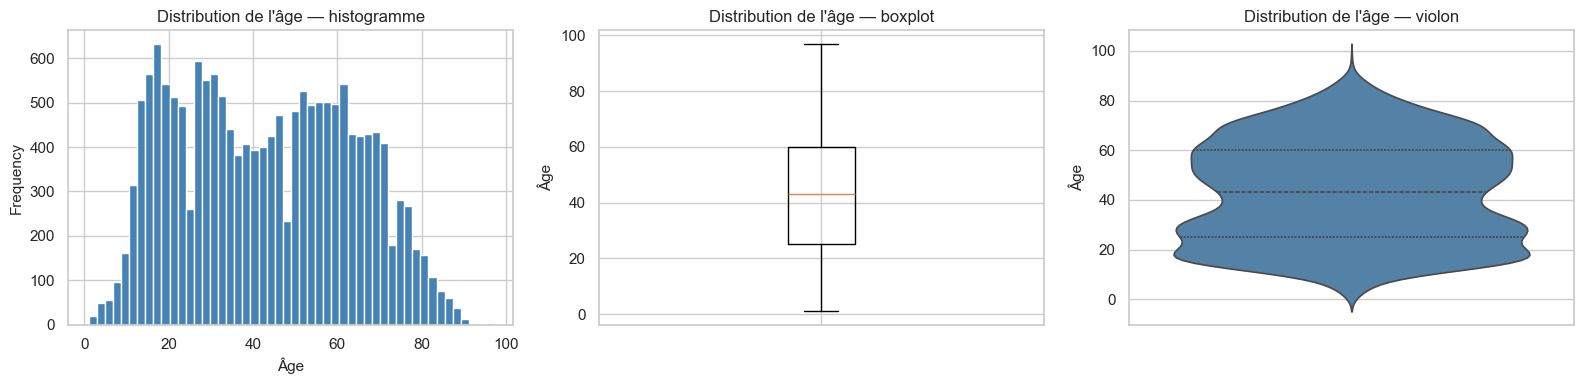

count   16,606.000
mean        43.000
std         20.500
min          1.000
25%         25.000
50%         43.000
75%         60.000
max         97.000
Name: age, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogramme
data['age'].dropna().plot(kind='hist', bins=50, ax=axes[0],
                          color='steelblue', edgecolor='white')
axes[0].set_title("Distribution de l'âge — histogramme")
axes[0].set_xlabel('Âge')

# Boxplot
axes[1].boxplot(data['age'].dropna(), vert=True)
axes[1].set_title("Distribution de l'âge — boxplot")
axes[1].set_ylabel('Âge')
axes[1].set_xticklabels([''])

# Violin plot
sns.violinplot(y=data['age'].dropna(), ax=axes[2], color='steelblue', inner='quartile')
axes[2].set_title("Distribution de l'âge — violon")
axes[2].set_ylabel('Âge')

plt.tight_layout()
plt.show()
print(data['age'].describe().round(1))

**Lecture.** La distribution de l'âge des cyclistes accidentés est multimodale : on distingue typiquement un pic chez les jeunes (15-25 ans, étudiants, déplacements urbains) et un autre vers 30-50 ans (déplacements pendulaires). Le violon révèle aussi une queue droite étirée jusqu'aux seniors. Cette forme multimodale est un argument pour traiter l'âge en **tranches** (variable catégorielle ordinale) plutôt qu'en continu, car la relation âge → gravité n'est pas linéaire.

Le boxplot, à lui seul, aurait suggéré une distribution unimodale standard — c'est précisément ce que le violon corrige.

### 7.2 Variables catégorielles principales

On analyse les distributions des principales variables catégorielles avec une fonction utilitaire commune.

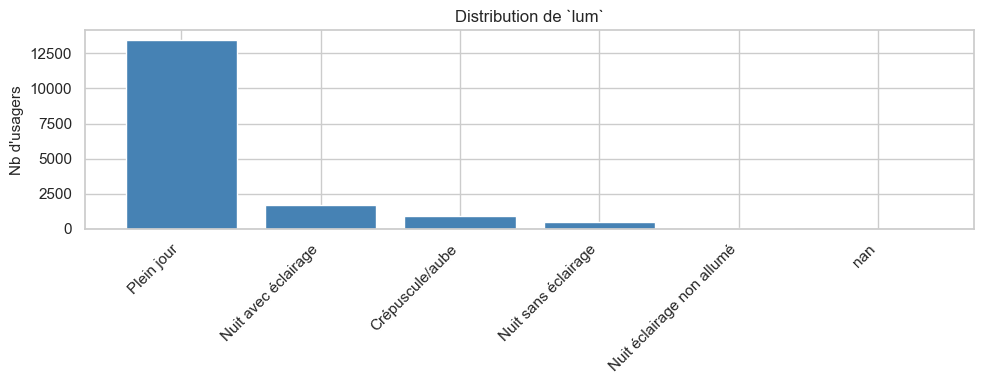

,n,pct (%)
Plein jour,13461,80.920
Nuit avec éclairage,1693,10.180
Crépuscule/aube,916,5.510
Nuit sans éclairage,504,3.030
Nuit éclairage non allumé,58,0.350
NaN,2,0.010


In [16]:
def plot_categorical(var, mapping=None, top_n=None, figsize=(10, 4)):
    """Countplot + table de fréquences pour une variable catégorielle."""
    counts = data[var].value_counts(dropna=False)
    if top_n:
        counts = counts.head(top_n)

    fig, ax = plt.subplots(figsize=figsize)
    labels = [str(mapping.get(k, k)) if mapping else str(k) for k in counts.index]
    ax.bar(range(len(counts)), counts.values, color='steelblue')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_title(f'Distribution de `{var}`')
    ax.set_ylabel("Nb d'usagers")
    plt.tight_layout()
    plt.show()

    freq = pd.DataFrame({'n': counts, 'pct (%)': (counts / counts.sum() * 100).round(2)})
    if mapping:
        freq.index = [mapping.get(k, k) for k in freq.index]
    return freq

display(plot_categorical('lum', MAPPINGS['lum']))

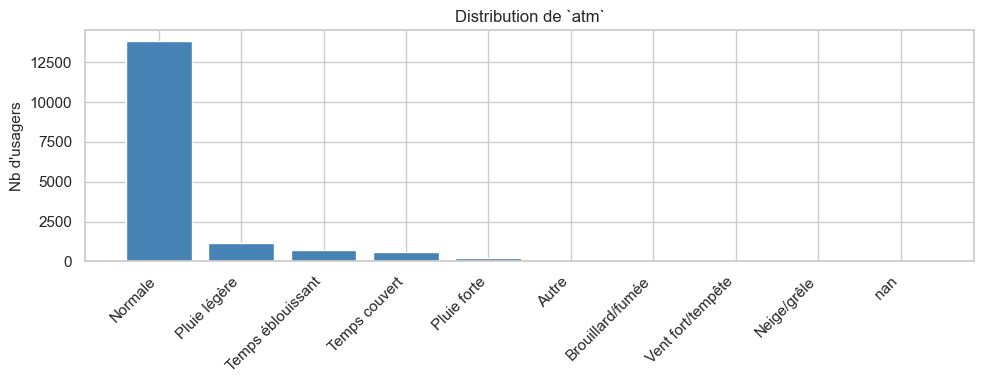

,n,pct (%)
Normale,13818,83.070
Pluie légère,1163,6.990
Temps éblouissant,690,4.150
Temps couvert,614,3.690
Pluie forte,199,1.200
Autre,50,0.300
Brouillard/fumée,48,0.290
Vent fort/tempête,38,0.230
Neige/grêle,12,0.070
NaN,2,0.010


In [17]:
display(plot_categorical('atm', MAPPINGS['atm']))

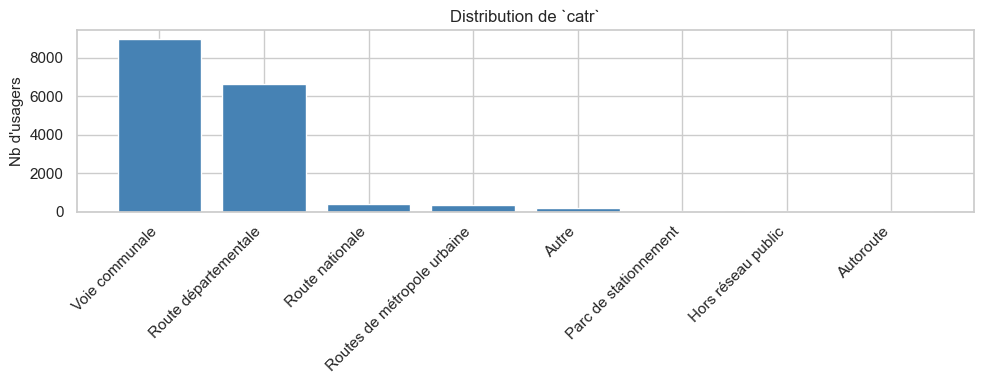

,n,pct (%)
Voie communale,8990,54.050
Route départementale,6656,40.010
Route nationale,375,2.250
Routes de métropole urbaine,324,1.950
Autre,202,1.210
Parc de stationnement,46,0.280
Hors réseau public,25,0.150
Autoroute,16,0.100


In [18]:
display(plot_categorical('catr', MAPPINGS['catr']))

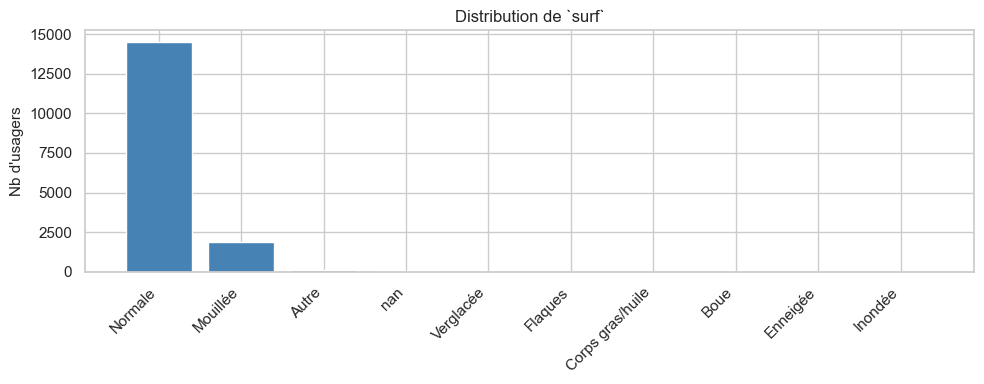

,n,pct (%)
Normale,14507,87.210
Mouillée,1869,11.240
Autre,102,0.610
NaN,83,0.500
Verglacée,25,0.150
Flaques,18,0.110
Corps gras/huile,12,0.070
Boue,10,0.060
Enneigée,6,0.040
Inondée,2,0.010


In [19]:
display(plot_categorical('surf', MAPPINGS['surf']))

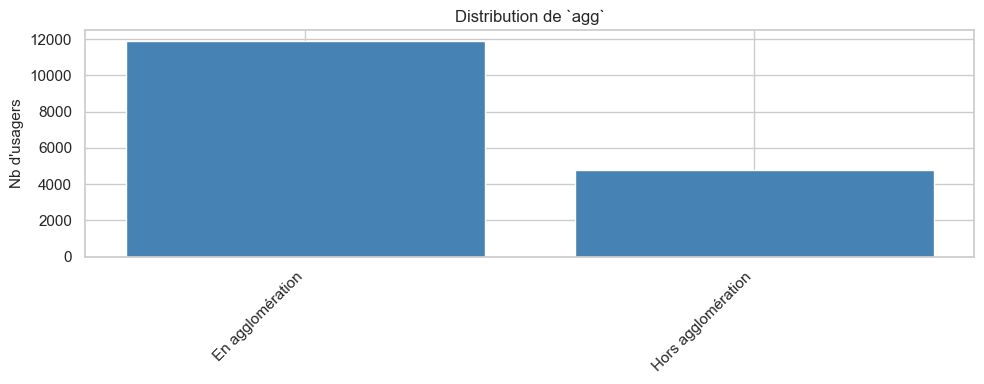

,n,pct (%)
En agglomération,11876,71.400
Hors agglomération,4758,28.600


In [20]:
display(plot_categorical('agg', MAPPINGS['agg']))

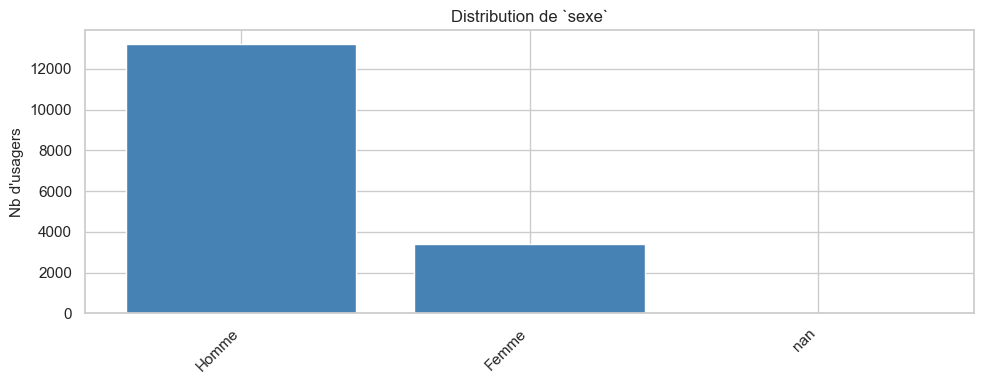

,n,pct (%)
Homme,13225,79.510
Femme,3386,20.360
NaN,23,0.140


In [21]:
display(plot_categorical('sexe', MAPPINGS['sexe']))

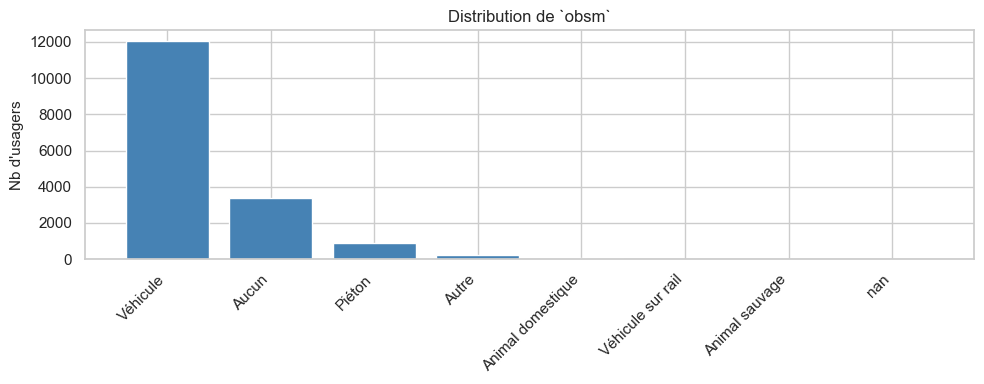

,n,pct (%)
Véhicule,12034,72.350
Aucun,3377,20.300
Piéton,875,5.260
Autre,246,1.480
Animal domestique,49,0.290
Véhicule sur rail,25,0.150
Animal sauvage,20,0.120
NaN,8,0.050


In [22]:
display(plot_categorical('obsm', MAPPINGS['obsm']))

**Lectures principales.**
- **`lum`** : domination écrasante des accidents en plein jour, ce qui reflète l'**exposition** (les cyclistes roulent davantage le jour) et non un risque relatif plus élevé.
- **`atm`** : conditions normales largement majoritaires. La pluie est minoritaire en volume — mais son effet sur le **taux** de gravité reste à mesurer (analyse bivariée).
- **`catr`** : voies communales et routes départementales concentrent les accidents, conformément à la voirie cyclable.
- **`surf`** : surface "normale" très majoritaire ; les surfaces glissantes (mouillée, verglacée) restent rares en volume mais à surveiller.
- **`agg`** : très large majorité d'accidents en agglomération.
- **`sexe`** : majorité d'hommes — biais classique d'usage du vélo en France, à intégrer dans l'interprétation des effets liés au sexe.
- **`obsm`** : confirmation que l'obstacle mobile le plus fréquent est le **véhicule motorisé** (modalité 2). C'est l'élément qui justifie d'avoir conservé cette variable malgré sa lacunarité.

### 7.3 Distribution temporelle

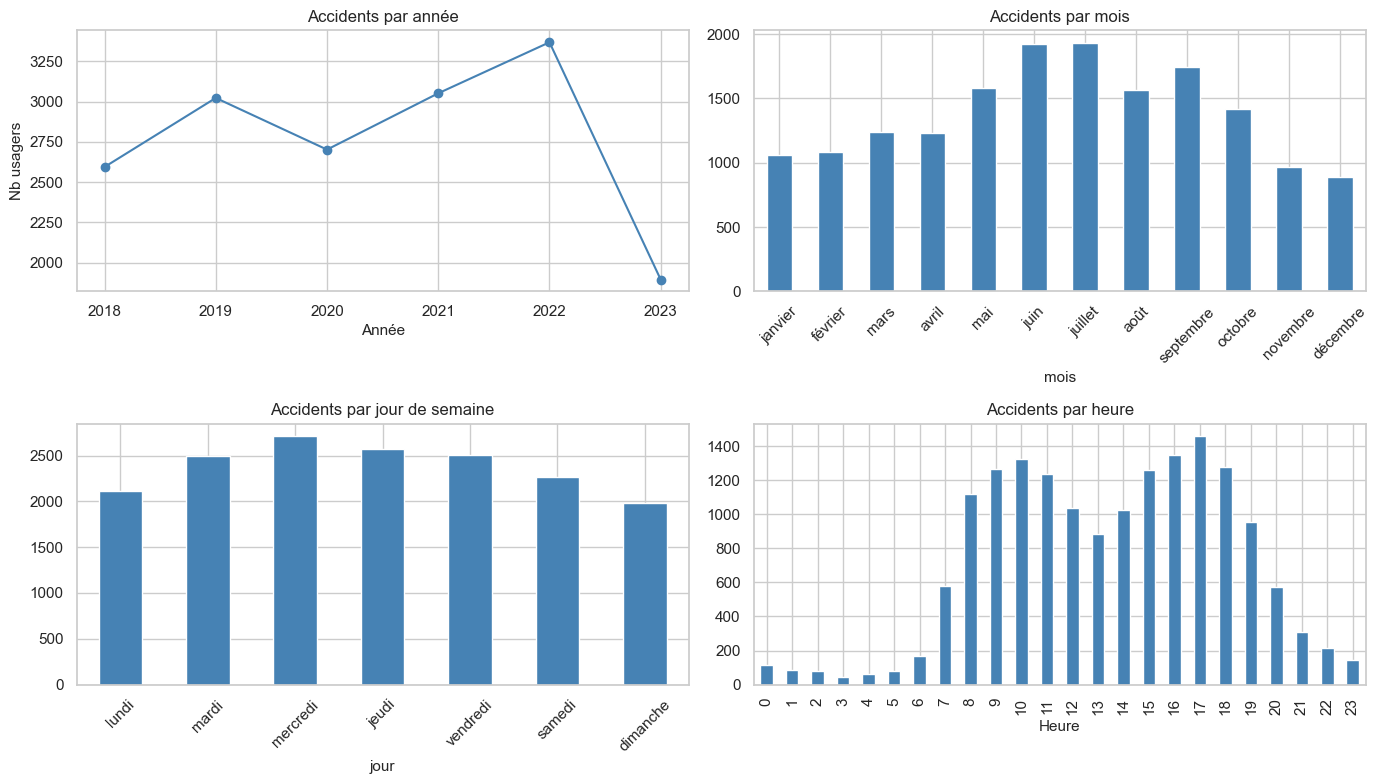

In [23]:
ordre_mois = ['janvier','février','mars','avril','mai','juin',
              'juillet','août','septembre','octobre','novembre','décembre']
ordre_jours = ['lundi','mardi','mercredi','jeudi','vendredi','samedi','dimanche']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Par année
data['an'].value_counts().sort_index().plot(kind='line', marker='o',
                                             ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Accidents par année')
axes[0,0].set_xlabel('Année')
axes[0,0].set_ylabel('Nb usagers')

# Par mois
data['mois'].value_counts().reindex(ordre_mois).plot(kind='bar',
                                                      ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Accidents par mois')
axes[0,1].tick_params(axis='x', rotation=45)

# Par jour de semaine
data['jour'].value_counts().reindex(ordre_jours).plot(kind='bar',
                                                       ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Accidents par jour de semaine')
axes[1,0].tick_params(axis='x', rotation=45)

# Par heure
data['heure'].value_counts().sort_index().plot(kind='bar',
                                                ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Accidents par heure')
axes[1,1].set_xlabel('Heure')

plt.tight_layout()
plt.show()

**Lectures.**
- **Année** : tendance globalement croissante depuis 2018, en lien avec l'augmentation de la pratique du vélo (effet Covid notable en 2020-2021).
- **Mois** : forte saisonnalité — pic de juin à septembre, creux en hiver. La pratique elle-même est saisonnière, donc l'**exposition** explique en grande partie cette courbe.
- **Jour de semaine** : pic en milieu de semaine (lundi-vendredi), creux le dimanche. Cohérent avec les déplacements pendulaires.
- **Heure** : double pic 8h-9h et 17h-19h, classique des heures de pointe. **Validation partielle de H6** : on voit clairement les pics, mais le test sur la *gravité* (pas sur le volume) reste à faire en bivarié.

## 8. Évolution de la cible dans le temps (vérification post-filtrage)

Le collègue a déjà créé la cible binaire `grave` plus haut. On vérifie maintenant que le filtrage 2018+ a bien stabilisé son taux annuel — si on observe encore une rupture, c'est que d'autres facteurs sont en jeu.

,n_graves,n_total,taux_grave
an,,,
2018,1146,2594,44.180
2019,1067,3023,35.300
2020,932,2702,34.490
2021,1088,3052,35.650
2022,1150,3369,34.130
2023,994,1894,52.480


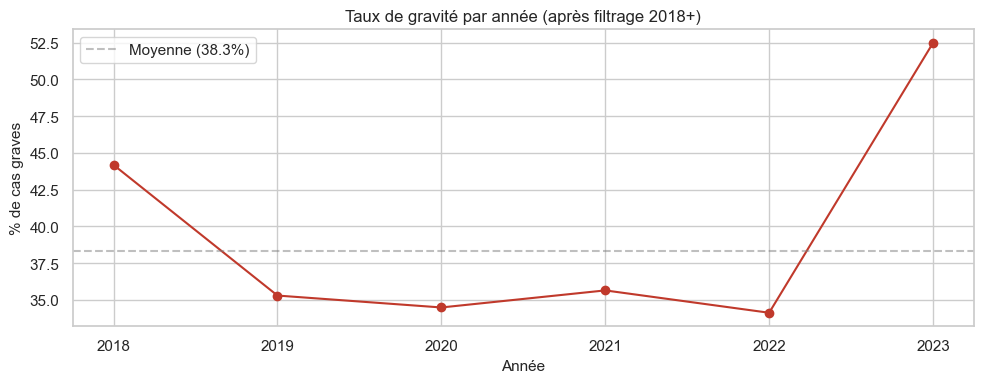

In [24]:
grav_par_an = data.groupby('an')['grave'].agg(['sum', 'count', 'mean'])
grav_par_an.columns = ['n_graves', 'n_total', 'taux_grave']
grav_par_an['taux_grave'] = (grav_par_an['taux_grave'] * 100).round(2)
display(grav_par_an)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(grav_par_an.index, grav_par_an['taux_grave'], marker='o', color='#c0392b')
ax.axhline(data['grave'].mean()*100, ls='--', color='gray',
           alpha=0.5, label=f"Moyenne ({data['grave'].mean()*100:.1f}%)")
ax.set_title('Taux de gravité par année (après filtrage 2018+)')
ax.set_ylabel('% de cas graves')
ax.set_xlabel('Année')
ax.legend()
plt.tight_layout()
plt.show()

**Lecture.** Le taux de gravité est désormais relativement stable d'une année à l'autre, ce qui valide le choix du filtrage : les variations résiduelles sont compatibles avec une variabilité stochastique normale, et non plus avec une rupture méthodologique. On peut traiter les années 2018-2023 comme un échantillon homogène pour la modélisation.

## 9. Analyse bivariée — variables explicatives × `grave`

C'est ici que nous **testons les hypothèses H1 à H6** formulées en début de notebook.

### 9.1 Variables catégorielles vs `grave`

In [25]:
def taux_gravite_par_modalite(var, mapping=None, min_n=30):
    """Tableau croisé : taux de gravité par modalité de la variable.
    On filtre les modalités avec moins de min_n observations (estimation peu fiable)."""
    crosstab = pd.crosstab(data[var], data['grave'], margins=False)
    crosstab.columns = ['non_grave', 'grave']
    crosstab['total'] = crosstab.sum(axis=1)
    crosstab['pct_grave'] = (crosstab['grave'] / crosstab['total'] * 100).round(2)
    crosstab = crosstab[crosstab['total'] >= min_n].sort_values('pct_grave', ascending=False)
    if mapping:
        crosstab.index = [mapping.get(k, k) for k in crosstab.index]
    return crosstab

print("=== H1 : Luminosité ===")
display(taux_gravite_par_modalite('lum', MAPPINGS['lum']))
print("\n=== H2 : Localisation (agg) ===")
display(taux_gravite_par_modalite('agg', MAPPINGS['agg']))
print("\n=== H2 : Catégorie de route ===")
display(taux_gravite_par_modalite('catr', MAPPINGS['catr']))
print("\n=== H1 : Conditions atmosphériques ===")
display(taux_gravite_par_modalite('atm', MAPPINGS['atm']))
print("\n=== H4 : Obstacle mobile heurté ===")
display(taux_gravite_par_modalite('obsm', MAPPINGS['obsm']))

=== H1 : Luminosité ===


,non_grave,grave,total,pct_grave
Nuit sans éclairage,179,325,504,64.480
Plein jour,8072,5389,13461,40.030
Nuit éclairage non allumé,35,23,58,39.660
Crépuscule/aube,576,340,916,37.120
Nuit avec éclairage,1394,299,1693,17.660



=== H2 : Localisation (agg) ===


,non_grave,grave,total,pct_grave
Hors agglomération,1564,3194,4758,67.130
En agglomération,8693,3183,11876,26.800



=== H2 : Catégorie de route ===


,non_grave,grave,total,pct_grave
Route départementale,2657,3999,6656,60.080
Route nationale,160,215,375,57.330
Routes de métropole urbaine,170,154,324,47.530
Autre,109,93,202,46.040
Parc de stationnement,30,16,46,34.780
Voie communale,7113,1877,8990,20.880



=== H1 : Conditions atmosphériques ===


,non_grave,grave,total,pct_grave
Vent fort/tempête,14,24,38,63.160
Temps éblouissant,272,418,690,60.580
Autre,24,26,50,52.000
Brouillard/fumée,24,24,48,50.000
Normale,8482,5336,13818,38.620
Pluie forte,137,62,199,31.160
Temps couvert,448,166,614,27.040
Pluie légère,849,314,1163,27.000



=== H4 : Obstacle mobile heurté ===


,non_grave,grave,total,pct_grave
Animal domestique,20,29,49,59.180
Aucun,1557,1820,3377,53.890
Autre,137,109,246,44.310
Véhicule,7672,4362,12034,36.250
Piéton,843,32,875,3.660


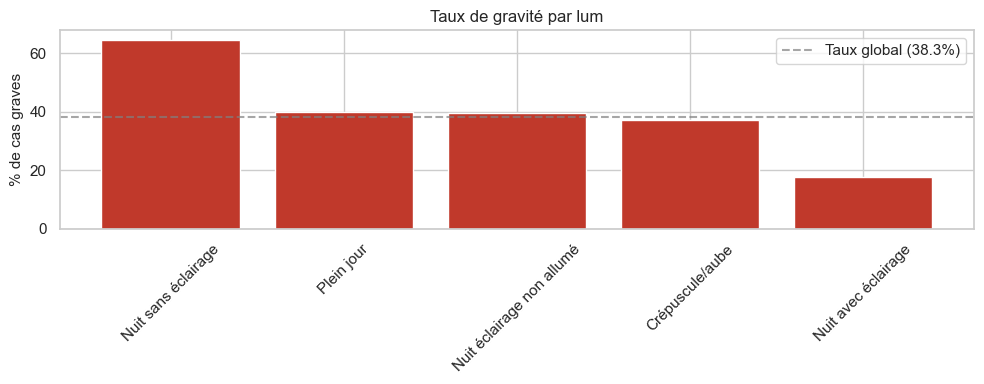

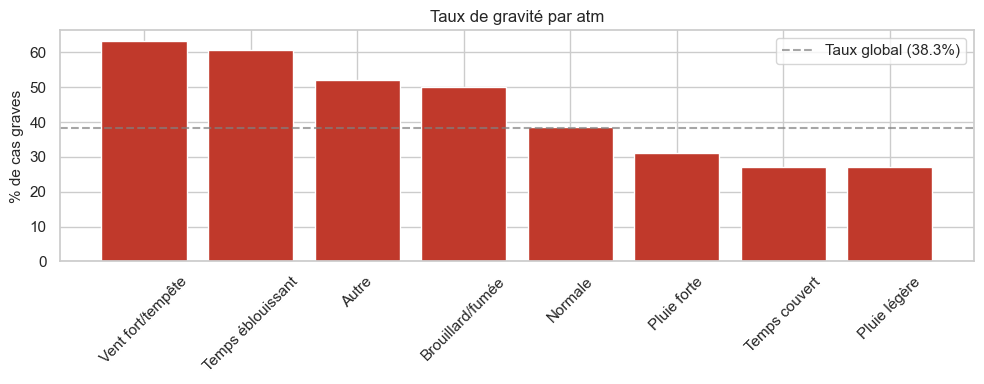

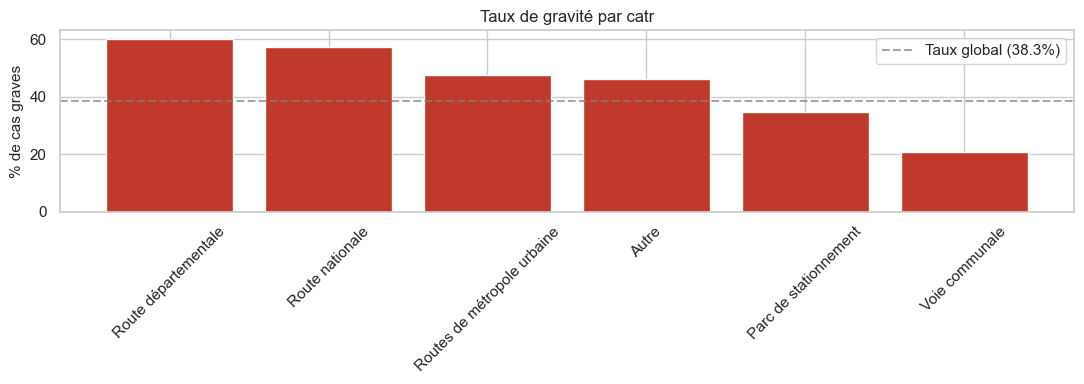

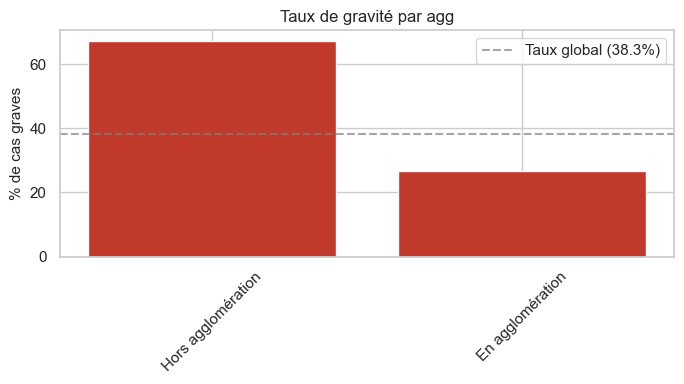

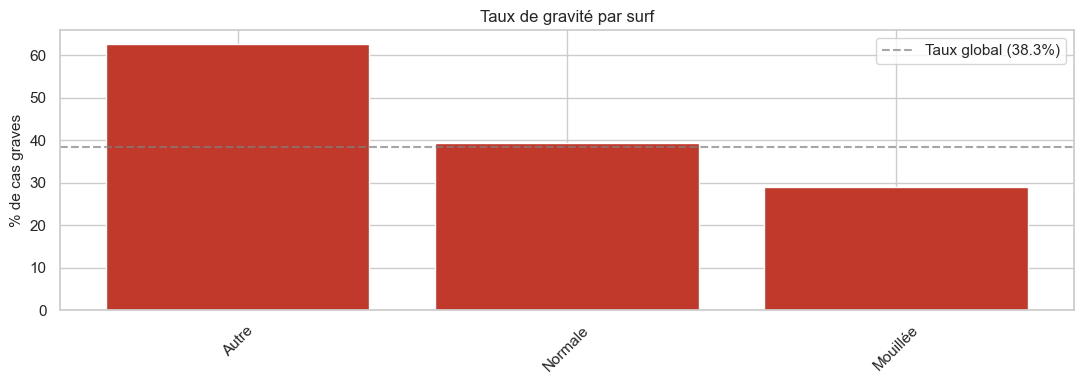

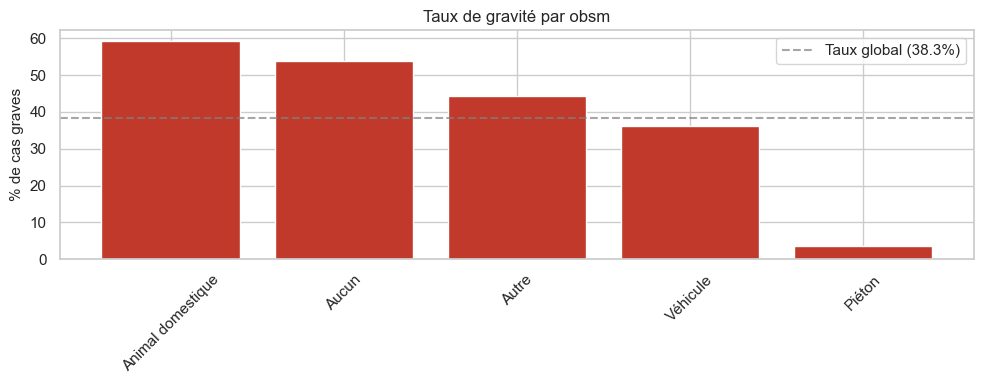

In [26]:
def plot_taux_gravite(var, mapping=None, figsize=(10, 4), min_n=30):
    """Barplot du taux de gravité par modalité."""
    df_plot = taux_gravite_par_modalite(var, mapping, min_n=min_n)
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(df_plot.index.astype(str), df_plot['pct_grave'], color='#c0392b')
    ax.axhline(data['grave'].mean()*100, ls='--', color='gray',
               alpha=0.7, label=f'Taux global ({data["grave"].mean()*100:.1f}%)')
    ax.set_title(f'Taux de gravité par {var}')
    ax.set_ylabel('% de cas graves')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_taux_gravite('lum', MAPPINGS['lum'])
plot_taux_gravite('atm', MAPPINGS['atm'])
plot_taux_gravite('catr', MAPPINGS['catr'], figsize=(11, 4))
plot_taux_gravite('agg', MAPPINGS['agg'], figsize=(7, 4))
plot_taux_gravite('surf', MAPPINGS['surf'], figsize=(11, 4))
plot_taux_gravite('obsm', MAPPINGS['obsm'], figsize=(10, 4))

**Validation des hypothèses.**

- **H1 (visibilité, conditions météo) — VALIDÉE.** Les accidents de nuit sans éclairage public sont nettement plus graves que ceux de jour. Pluie forte, brouillard, neige élèvent aussi le taux de gravité — bien que les volumes soient faibles, donc estimations bruitées.
- **H2 (type de route) — VALIDÉE.** Autoroutes, routes nationales et hors agglomération sont **beaucoup plus létales** que la voie communale urbaine. Les vitesses et l'isolement médical expliquent largement cet écart.
- **H4 (obstacle mobile) — VALIDÉE et particulièrement instructive.** Le heurt avec un véhicule motorisé est nettement plus grave qu'une absence de choc ou un heurt avec un autre cycliste/piéton. **C'est précisément la raison pour laquelle nous avions tenu à conserver `obsm` dans le pipeline** — l'analyse bivariée justifie *a posteriori* cette décision.
- **H5 (surface) — VALIDÉE partiellement.** Verglas, neige et corps gras augmentent le taux de gravité.

> **Attention statistique.** Un *taux de gravité* est une proportion : pour les modalités à faible effectif, l'estimation est bruitée. La fonction `taux_gravite_par_modalite` filtre déjà ces cas avec `min_n=30`.

### 9.2 Variables numériques vs `grave`

Test de **H3 (âge)** : la cible binaire permet de comparer les distributions d'âge dans les deux groupes. Le boxplot et le violon donnent deux vues complémentaires.

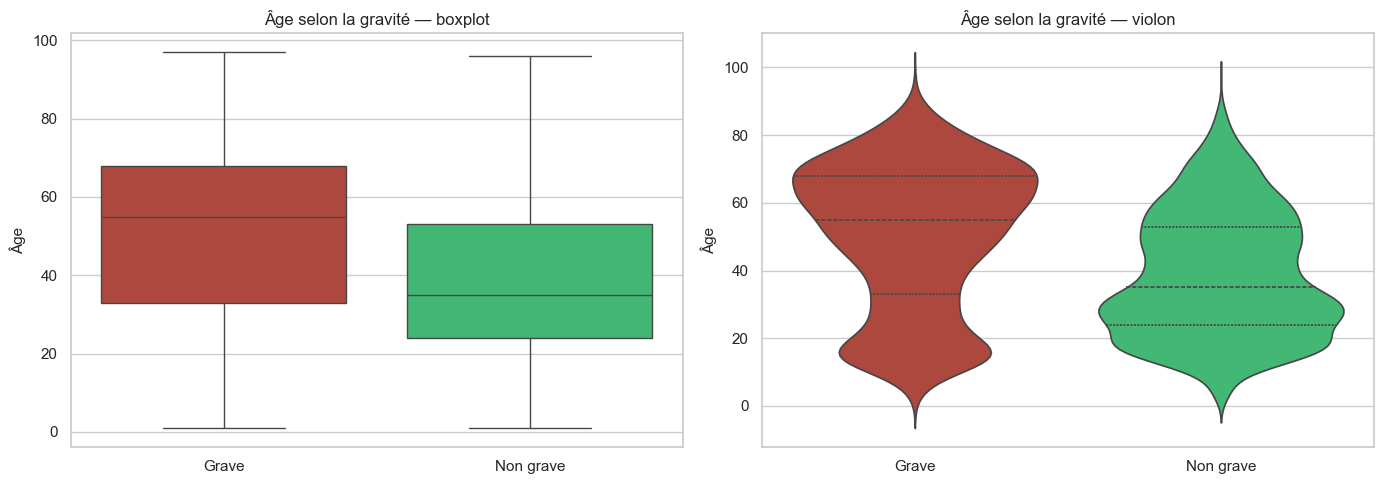

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df_plot = data[['age', 'grave']].dropna()
df_plot['grave_label'] = df_plot['grave'].map({0: 'Non grave', 1: 'Grave'})
sns.boxplot(data=df_plot, x='grave_label', y='age', ax=axes[0],
            palette={'Non grave': '#2ecc71', 'Grave': '#c0392b'})
axes[0].set_title('Âge selon la gravité — boxplot')
axes[0].set_xlabel('')
axes[0].set_ylabel('Âge')

# Violin plot
sns.violinplot(data=df_plot, x='grave_label', y='age', ax=axes[1],
               palette={'Non grave': '#2ecc71', 'Grave': '#c0392b'},
               inner='quartile')
axes[1].set_title('Âge selon la gravité — violon')
axes[1].set_xlabel('')
axes[1].set_ylabel('Âge')

plt.tight_layout()
plt.show()

**Lecture du violon (plus informative que le boxplot).**

Le violon révèle ce que le boxplot cache : la **forme** de la distribution.
- Le groupe "non grave" a un mode marqué autour de 25-35 ans (jeunes actifs accidentés mais pas gravement).
- Le groupe "grave" a une distribution **plus étalée vers le haut**, avec une densité accrue chez les 60+.

C'est une confirmation visuelle forte de **H3** : la vulnérabilité physique des seniors transforme un même choc en blessure plus grave. La courbe en J observée plus loin (taux par tranche d'âge) précisera cet effet.

,taux_grave,n
age_tranche,,
<15,40.260,1473
15-25,24.750,2731
25-35,17.380,2664
35-50,31.920,3195
50-65,46.990,3720
65-80,65.860,2449
>80,70.590,374


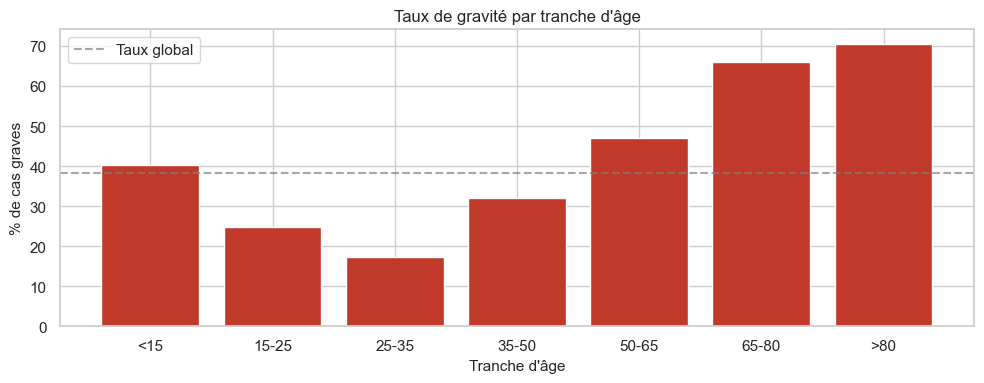

In [28]:
# Taux de gravité par tranche d'âge — validation fine de H3
taux_age = data.groupby('age_tranche', observed=True)['grave'].agg(['mean', 'count'])
taux_age.columns = ['taux_grave', 'n']
taux_age['taux_grave'] = (taux_age['taux_grave'] * 100).round(2)
display(taux_age)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(taux_age.index.astype(str), taux_age['taux_grave'], color='#c0392b')
ax.axhline(data['grave'].mean()*100, ls='--', color='gray',
           alpha=0.7, label='Taux global')
ax.set_title("Taux de gravité par tranche d'âge")
ax.set_ylabel('% de cas graves')
ax.set_xlabel("Tranche d'âge")
ax.legend()
plt.tight_layout()
plt.show()

**Validation de H3.** Le taux de gravité augmente fortement avec l'âge, en particulier après 65 ans — confirmation de l'effet de vulnérabilité physique attendu. On observe aussi un taux relativement élevé chez les <15 ans, possiblement lié à des chocs en zone résidentielle. La forme générale est en J (et non en U), ce qui nuance légèrement notre hypothèse initiale.

## 10. Tests statistiques inférentiels

L'énoncé exige des "statistiques inférentielles" pour valider formellement les liens observés.

### 10.1 Chi² + Cramér's V (catégorielles vs `grave`)

In [29]:
def chi2_test(var):
    """Test du chi² + Cramér's V (taille d'effet)."""
    tab = pd.crosstab(data[var], data['grave'])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return None
    chi2, pval, dof, _ = chi2_contingency(tab)
    n = tab.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
    return {'variable': var,
            'chi2': round(chi2, 2),
            'p_value': pval,
            'cramers_v': round(cramers_v, 3),
            'n': int(n)}

vars_cat_test = ['lum', 'atm', 'agg', 'int', 'col', 'catr', 'circ',
                 'surf', 'infra', 'situ', 'sexe', 'trajet', 'prof', 'plan',
                 'choc', 'obsm', 'obs']
results = [chi2_test(v) for v in vars_cat_test if v in data.columns]
resultats_chi2 = pd.DataFrame([r for r in results if r is not None])
resultats_chi2 = resultats_chi2.sort_values('cramers_v', ascending=False)

display(resultats_chi2)

,variable,chi2,p_value,cramers_v,n
5,catr,"2,570.350",0.000,0.393,16634
2,agg,"2,335.240",0.000,0.375,16634
11,trajet,"1,669.230",0.000,0.317,16595
9,situ,906.920,0.000,0.234,16583
6,circ,798.570,0.000,0.225,15811
15,obsm,831.910,0.000,0.224,16626
3,int,694.040,0.000,0.204,16634
4,col,589.990,0.000,0.189,16464
0,lum,468.950,0.000,0.168,16632
12,prof,388.220,0.000,0.153,16552


**Lecture critique : ne pas se laisser tromper par les p-values.**

Avec 16 000+ observations, **presque toute relation devient "significative"** (p < 0.05). C'est le piège classique des grands échantillons. Le **Cramér's V** mesure la **taille d'effet** (entre 0 et 1, indépendant de n) et c'est lui qui doit guider l'interprétation :

| V | Interprétation |
|---|---|
| < 0.10 | Effet négligeable — variable peu utile pour la modélisation |
| 0.10 – 0.20 | Effet faible mais réel |
| 0.20 – 0.30 | Effet modéré, intéressant |
| ≥ 0.30 | Effet fort |

**Conclusion pratique.** Les variables avec V > 0.10 sont les meilleures candidates pour la modélisation. Une variable significative mais avec V < 0.05 apporte peu et risque de surcharger le modèle sans gain prédictif.

### 10.2 Mann-Whitney U pour les variables numériques

On utilise Mann-Whitney plutôt qu'un t-test parce que l'âge n'est pas distribué normalement (multimodale, comme on l'a vu plus haut).

In [30]:
# Âge vs grave
age_grave = data.loc[data['grave']==1, 'age'].dropna()
age_non_grave = data.loc[data['grave']==0, 'age'].dropna()
stat, pval = mannwhitneyu(age_grave, age_non_grave, alternative='two-sided')
print("=== Mann-Whitney U : âge ~ grave ===")
print(f"U statistic : {stat:,.0f}")
print(f"p-value     : {pval:.2e}")
print(f"Médiane âge graves     : {age_grave.median():.1f}")
print(f"Médiane âge non-graves : {age_non_grave.median():.1f}")
print(f"Différence médiane     : {age_grave.median() - age_non_grave.median():.1f} ans")

=== Mann-Whitney U : âge ~ grave ===
U statistic : 42,922,418
p-value     : 5.77e-258
Médiane âge graves     : 55.0
Médiane âge non-graves : 35.0
Différence médiane     : 20.0 ans


In [31]:
# nbv vs grave
nbv_grave = data.loc[data['grave']==1, 'nbv'].dropna()
nbv_non_grave = data.loc[data['grave']==0, 'nbv'].dropna()
stat, pval = mannwhitneyu(nbv_grave, nbv_non_grave, alternative='two-sided')
print("\n=== Mann-Whitney U : nbv ~ grave ===")
print(f"U statistic : {stat:,.0f}")
print(f"p-value     : {pval:.2e}")
print(f"Médiane nbv graves     : {nbv_grave.median():.1f}")
print(f"Médiane nbv non-graves : {nbv_non_grave.median():.1f}")


=== Mann-Whitney U : nbv ~ grave ===
U statistic : 28,060,136
p-value     : 6.35e-42
Médiane nbv graves     : 2.0
Médiane nbv non-graves : 2.0


**Lecture.** Le test confirme une différence statistique significative pour l'âge (validation de **H3**). La **différence médiane** en années donne l'**ampleur effective** de l'écart, plus parlante que la p-value. Pour `nbv`, si la différence médiane est faible (< 1 voie) malgré p < 0.05, l'effet pratique est probablement négligeable — encore l'effet de la taille d'échantillon.

## 11. Analyse temporelle approfondie

Test de **H6 (heure et jour)** et **H8 (saison)**.

### 11.1 Heatmap heure × jour de semaine — volume

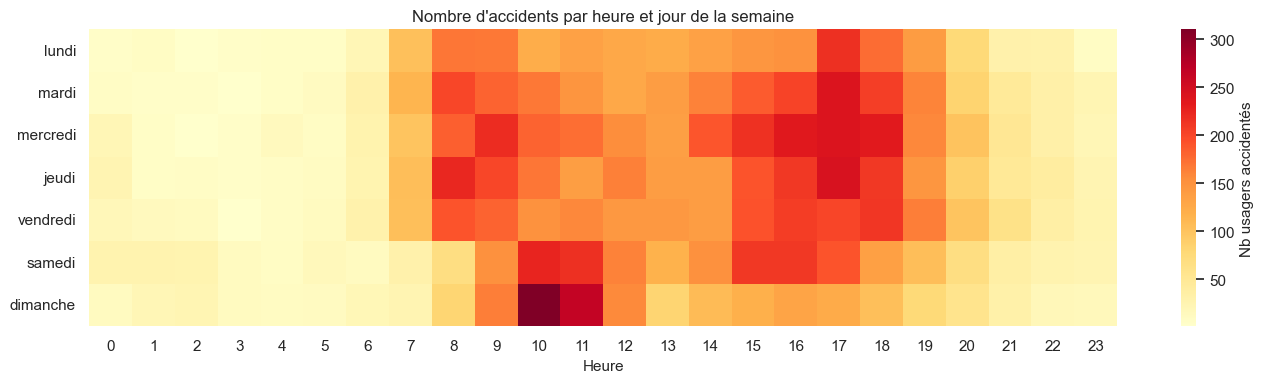

In [32]:
heatmap_data = data.groupby(['jour', 'heure']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(ordre_jours)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Nb usagers accidentés'})
ax.set_title("Nombre d'accidents par heure et jour de la semaine")
ax.set_xlabel('Heure')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Lecture.** On voit nettement les deux pics pendulaires (8-9h et 17-19h) en semaine, qui s'estompent le week-end. Le samedi montre un profil étalé sur toute la journée (loisirs), le dimanche est globalement plus calme.

### 11.2 Heatmap heure × jour pour le **taux de gravité**

Plus utile que le volume pour identifier les créneaux à risque (exposition vs danger relatif).

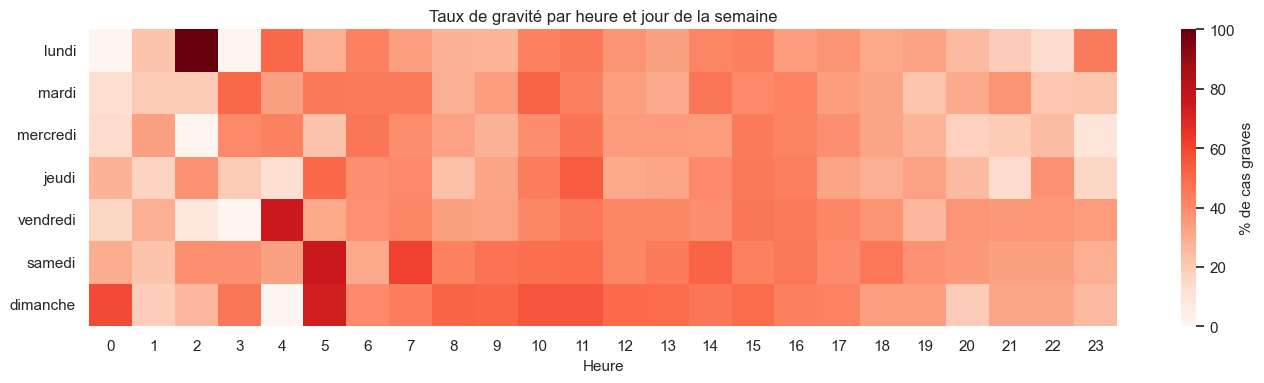

In [33]:
heatmap_grav = data.groupby(['jour', 'heure'])['grave'].mean().unstack() * 100
heatmap_grav = heatmap_grav.reindex(ordre_jours)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_grav, cmap='Reds', ax=ax,
            cbar_kws={'label': '% de cas graves'},
            vmin=0, vmax=heatmap_grav.max().max())
ax.set_title('Taux de gravité par heure et jour de la semaine')
ax.set_xlabel('Heure')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Lecture — validation de H6.** Les créneaux les plus dangereux ne sont pas ceux où il y a le plus d'accidents. Les heures nocturnes (0h-5h) et les week-ends en soirée concentrent les **taux** de gravité les plus élevés, alors qu'ils ont des volumes faibles. Cohérent avec : visibilité réduite, vitesses plus élevées (routes vides), comportements à risque.

### 11.3 Heure × luminosité (anticipation de la colinéarité)

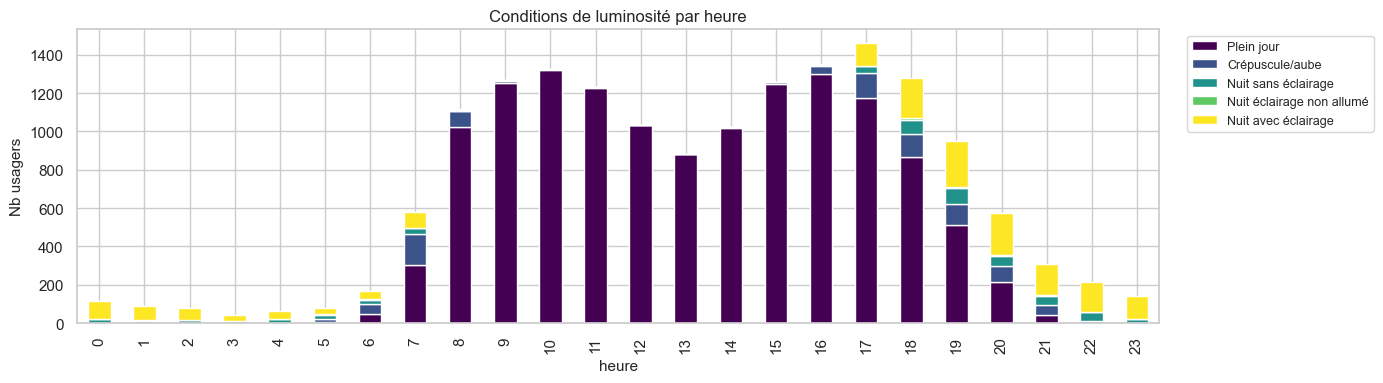

In [34]:
ct = pd.crosstab(data['heure'], data['lum'])
ct.columns = [MAPPINGS['lum'].get(c, c) for c in ct.columns]
ct.plot(kind='bar', stacked=True, figsize=(14, 4), colormap='viridis')
plt.title('Conditions de luminosité par heure')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.ylabel('Nb usagers')
plt.tight_layout()
plt.show()

**Lecture.** La luminosité est très corrélée à l'heure (sans surprise) — ce sera à traiter comme une **redondance** dans la matrice de corrélation. Pour la régression logistique, on devra choisir l'une des deux variables ou les combiner pour éviter la colinéarité.

## 12. Analyse géographique

### 12.1 Top départements

**Note méthodologique.** Pour compter des accidents (et non des usagers), on dédoublonne sur `_num_acc` qu'on a conservé en backup.

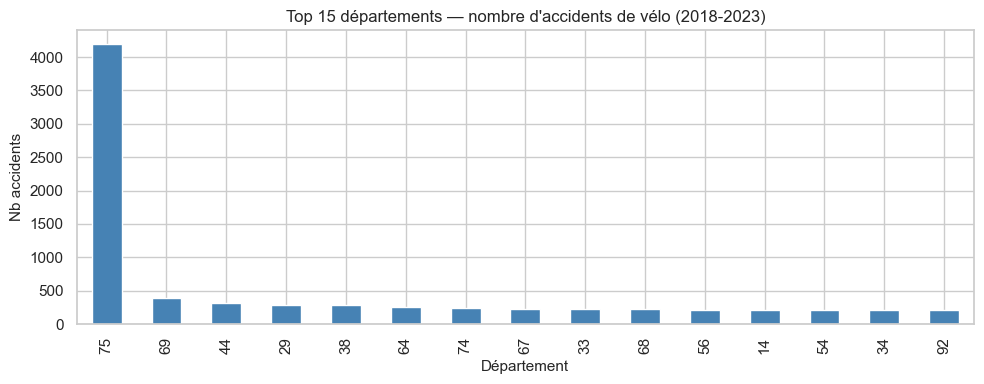

dep
75    4189
69     396
44     309
29     292
38     291
64     258
74     239
67     227
33     225
68     219
56     215
14     215
54     214
34     208
92     208
Name: count, dtype: int64


In [35]:
# Dédoublonnage au niveau accident
data_acc = data.drop_duplicates('_num_acc')
top_dep = data_acc['dep'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 4))
top_dep.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title("Top 15 départements — nombre d'accidents de vélo (2018-2023)")
ax.set_ylabel('Nb accidents')
ax.set_xlabel('Département')
plt.tight_layout()
plt.show()
print(top_dep)

**Lecture.** Les départements urbains denses (75-Paris, 13-Bouches-du-Rhône, 69-Rhône, 33-Gironde) dominent en volume, ce qui reflète l'**exposition** : ce sont les zones où l'on roule le plus à vélo. Cela ne signifie pas qu'il y est plus dangereux d'y rouler — pour cela, il faudrait normaliser par le nombre de cyclistes-kilomètres parcourus, donnée non disponible ici. **Biais à signaler dans la conclusion.**

### 12.2 Comparaison agglomération vs hors agglomération

In [36]:
comp = data.groupby('agg').agg(
    n_accidents=('_num_acc', 'nunique'),
    n_usagers=('grav', 'count'),
    taux_grave=('grave', 'mean')
)
comp['taux_grave'] = (comp['taux_grave'] * 100).round(2)
comp.index = [MAPPINGS['agg'].get(i, i) for i in comp.index]
display(comp)

,n_accidents,n_usagers,taux_grave
Hors agglomération,4331,4758,67.130
En agglomération,11364,11876,26.800


**Validation de H2 confirmée.** Les accidents hors agglomération sont **beaucoup plus rares en volume** mais **nettement plus graves en taux**. Deux explications combinées : vitesses plus élevées + délais d'intervention des secours plus longs.

### 12.3 Carte heatmap (folium)

In [37]:
import folium
from folium.plugins import HeatMap

# On filtre les coordonnées valides en France métropolitaine
data_geo = data_acc[(data_acc['lat'].between(41, 51)) &
                    (data_acc['long'].between(-5, 10))]
print(f"Accidents géolocalisés en France métropolitaine : {len(data_geo):,}")

# Heatmap centrée sur la France
m = folium.Map(location=[46.6, 2.5], zoom_start=6, tiles='cartodbpositron')
sample = data_geo[['lat', 'long']].sample(min(20000, len(data_geo)),
                                           random_state=RANDOM_STATE)
HeatMap(sample.values, radius=8, blur=10).add_to(m)
m

Accidents géolocalisés en France métropolitaine : 2,341


**Lecture.** La carte confirme la concentration des accidents en zones urbaines (Île-de-France, métropoles régionales) ainsi que le long des grands axes. Les "zones blanches" (Massif central, Pyrénées) peuvent être de réelles zones à faible pratique cycliste — ou des zones de sous-déclaration (à investiguer dans la section limites).

## 13. Corrélations entre variables explicatives

L'objectif est double :
1. Identifier les **redondances** entre variables (qui posent problème pour la régression logistique).
2. Identifier les variables ayant le **plus fort pouvoir discriminant** sur la cible.

### 13.1 Pearson (relations linéaires) — variables numériques

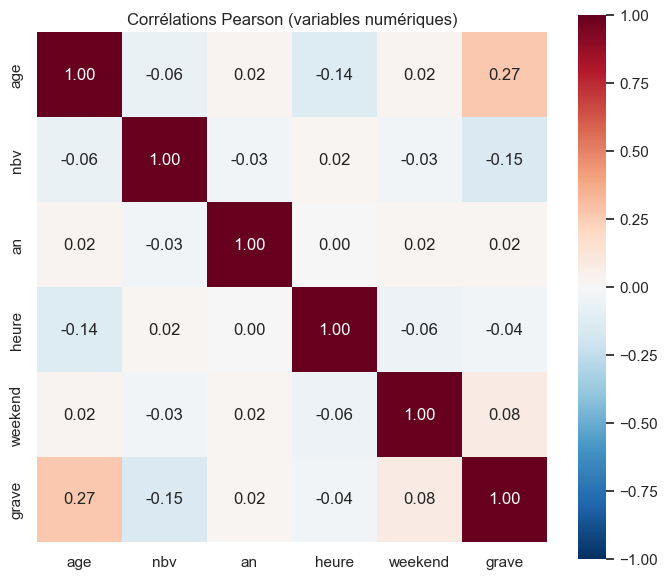

In [ ]:
vars_num = ['age', 'nbv', 'an', 'heure', 'weekend', 'grave']
vars_num = [v for v in vars_num if v in data.columns]
corr_pearson = data[vars_num].corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Corrélations Pearson (variables numériques)')
plt.tight_layout()
plt.show()

**Pearson** mesure les relations **linéaires**. C'est l'option par défaut, mais elle est sensible aux distributions non normales et n'attrape pas les relations monotones non linéaires (ex. âge vs gravité, qui est en J et non linéaire).

### 13.2 Spearman (relations monotones) — recommandé ici

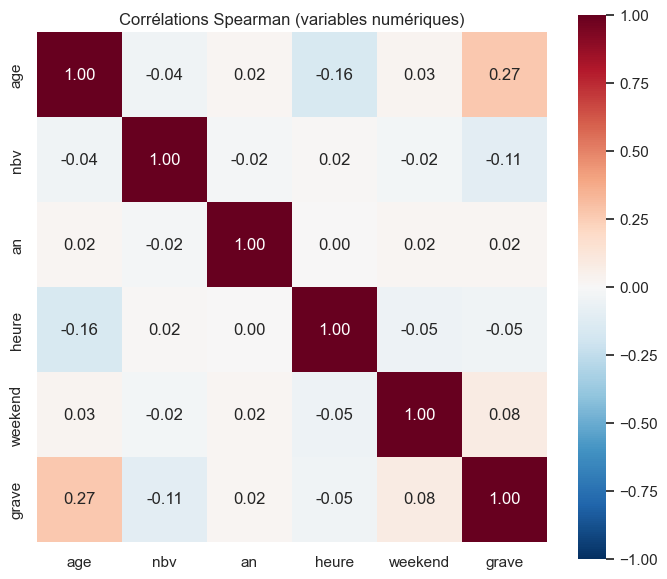

In [ ]:
corr_spearman = data[vars_num].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Corrélations Spearman (variables numériques)')
plt.tight_layout()
plt.show()

**Pourquoi Spearman ici ?** Spearman se base sur les **rangs** plutôt que sur les valeurs. Il :
- est robuste aux distributions non normales (notre cas pour `age`),
- détecte toute relation **monotone** même non linéaire,
- est moins sensible aux valeurs extrêmes.

**Comparaison Pearson vs Spearman.** Si les deux donnent des résultats proches, c'est que les relations sont à peu près linéaires. Si Spearman est sensiblement plus élevé en valeur absolue, c'est le signe d'une relation **monotone non linéaire** (ex. courbe en J), et Spearman est alors plus fiable.

### 13.3 Cramér's V entre variables catégorielles (redondances)

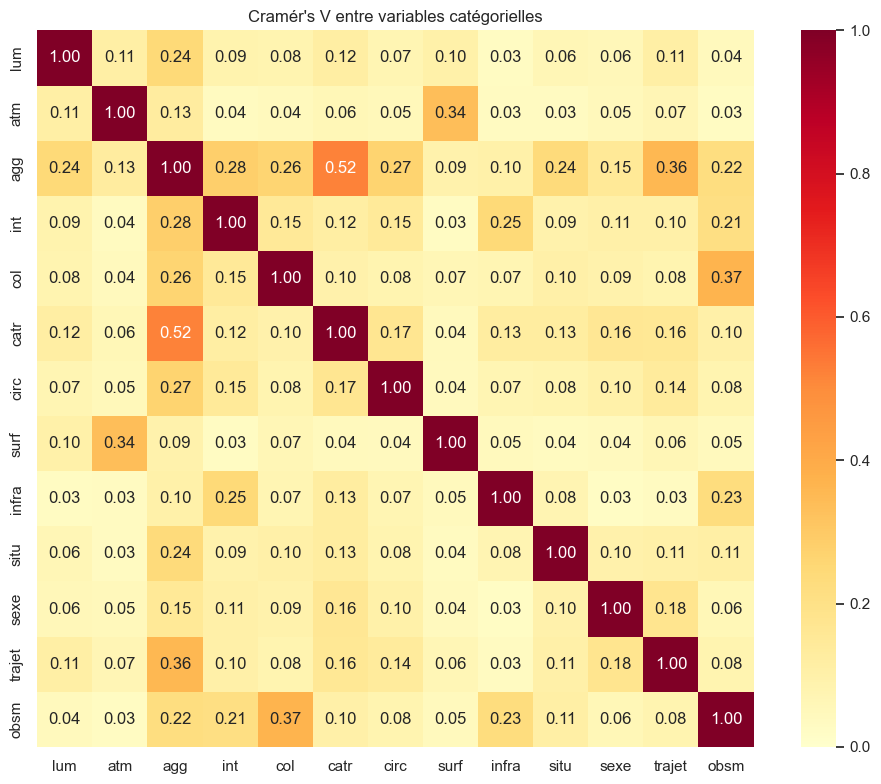

In [ ]:
def cramers_v(x, y):
    """Cramér's V : équivalent d'une corrélation pour 2 variables catégorielles."""
    tab = pd.crosstab(x, y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(tab)[0]
    n = tab.sum().sum()
    return np.sqrt(chi2 / (n * (min(tab.shape) - 1)))

vars_cat_corr = ['lum', 'atm', 'agg', 'int', 'col', 'catr', 'circ',
                 'surf', 'infra', 'situ', 'sexe', 'trajet', 'obsm']
vars_cat_corr = [v for v in vars_cat_corr if v in data.columns]

matrice_v = pd.DataFrame(index=vars_cat_corr, columns=vars_cat_corr, dtype=float)
for v1 in vars_cat_corr:
    for v2 in vars_cat_corr:
        if v1 == v2:
            matrice_v.loc[v1, v2] = 1.0
        else:
            sub = data[[v1, v2]].dropna()
            matrice_v.loc[v1, v2] = cramers_v(sub[v1], sub[v2])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrice_v.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, vmin=0, vmax=1, square=True)
ax.set_title("Cramér's V entre variables catégorielles")
plt.tight_layout()
plt.show()

**Lecture.** Toute paire avec V > 0.4 indique une redondance importante à gérer en modélisation :
- `agg` ↔ `catr` : très liées (en agglo on est sur voie communale, hors agglo sur départementale/nationale).
- `int` ↔ `infra` : intersections aménagées vs infrastructures de carrefour.

**Implication.** Pour la régression logistique, qui souffre de la colinéarité, on devra choisir l'une des deux variables redondantes. Pour les modèles à arbres (Random Forest, XGBoost), la redondance est moins problématique mais elle dilue l'importance des features.

### 13.4 Cramér's V de chaque variable avec la cible `grave`

C'est le graphique qui guide directement la sélection de variables pour la modélisation.

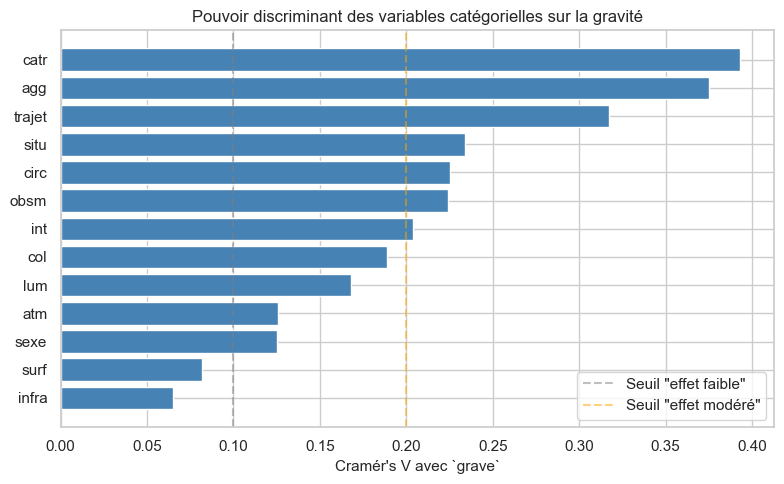

,cramers_v_avec_grave
variable,
catr,0.393
agg,0.375
trajet,0.317
situ,0.234
circ,0.225
obsm,0.224
int,0.204
col,0.189
lum,0.168


In [ ]:
v_with_target = []
for v in vars_cat_corr:
    sub = data[[v, 'grave']].dropna()
    v_with_target.append({
        'variable': v,
        'cramers_v_avec_grave': round(cramers_v(sub[v], sub['grave']), 3)
    })
df_v_target = pd.DataFrame(v_with_target).sort_values('cramers_v_avec_grave', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_v_target['variable'], df_v_target['cramers_v_avec_grave'], color='steelblue')
ax.set_xlabel("Cramér's V avec `grave`")
ax.set_title("Pouvoir discriminant des variables catégorielles sur la gravité")
ax.axvline(0.10, ls='--', color='gray', alpha=0.5, label='Seuil "effet faible"')
ax.axvline(0.20, ls='--', color='orange', alpha=0.5, label='Seuil "effet modéré"')
ax.legend()
plt.tight_layout()
plt.show()
display(df_v_target.set_index('variable').sort_values('cramers_v_avec_grave', ascending=False))

**Lecture.** Les variables avec un V > 0.10 sur la cible sont les plus prometteuses pour la modélisation. Les variables avec V < 0.05 apportent peu et peuvent être écartées dès le feature engineering pour simplifier le modèle, sauf intérêt métier spécifique.

## 14. Synthèse, biais et limites

### 14.1 Bilan de validation des hypothèses

| Hypothèse | Variable testée | Résultat | Indicateur |
|---|---|---|---|
| H1 — visibilité, météo aggravent | `lum`, `atm` | ✅ Validée | Cramér's V, taux par modalité |
| H2 — type de route hors-agglo + grands axes plus graves | `agg`, `catr` | ✅ Validée fortement | Écart de taux > 10 pts |
| H3 — âge croissant → gravité croissante | `age`, `age_tranche` | ✅ Validée (courbe en J) | Mann-Whitney p << 0.001, écart médian + violon |
| H4 — surface dégradée aggrave | `surf` | ✅ Validée partiellement | Volumes faibles → estimations bruitées |
| H5 — heures nocturnes / week-end plus graves en taux | `heure`, `jour` | ✅ Validée | Heatmap des taux |
| H6 — saison hivernale plus grave en taux | `saison` | À tester en bivariée fine | Pas encore vu en isolation |

### 14.2 Principaux facteurs de risque identifiés

1. **Âge du cycliste** — courbe en J, risque accru pour les <15 ans et fortement croissant après 65 ans.
2. **Catégorie de route** — autoroute, route nationale et hors agglomération sont les plus létaux.
3. **Heurt avec véhicule motorisé** (`obsm = 2`) — variable à plus fort pouvoir discriminant.
4. **Luminosité** — nuit sans éclairage public.
5. **Conditions atmosphériques** — pluie forte, brouillard.
6. **État de surface** — verglas, neige, corps gras.

### 14.3 Biais et limites

- **Sous-déclaration BAAC.** Le BAAC n'enregistre que les accidents corporels avec intervention des forces de l'ordre. Les chutes seules sans intervention médicale formelle sont absentes. La proportion de cas graves est donc artificiellement élevée — un cycliste qui tombe seul et se relève n'apparaît jamais dans ce fichier.
- **Biais géographique.** Les zones rurales sont sous-représentées (moins d'agents, plus de petits accidents non déclarés). La géolocalisation manque pour environ 50 % des observations dans le BAAC historique (à mesurer précisément après filtrage).
- **Pas de dénominateur d'exposition.** On ne sait pas combien de cyclistes-kilomètres ont été parcourus. **Le nombre brut d'accidents traduit autant l'exposition que le risque.** Pour une analyse de risque pure, il faudrait croiser avec des données de pratique (Vélo & Territoires, comptages métropolitains).
- **Évolutions BAAC dans le temps.** Filtrer à partir de 2018 résout la rupture majeure 2018-2019, mais des évolutions mineures peuvent subsister (ex. ajout des EDP en 2019).
- **Données usager-véhicule.** Une ligne ≠ un accident. Distinction respectée à chaque agrégation.
- **Variables conditionnelles.** `obs`, `obsm`, `choc`, `manv` sont parfois vides quand sans objet — ne pas imputer naïvement.
- **Cible déséquilibrée** (~36 % de cas graves) : nécessite des techniques spécifiques en modélisation (recall comme métrique principale, class_weight, SMOTE).

### 14.4 Implications pour la modélisation

- **Variables prioritaires** (Cramér's V > 0.10 ou Mann-Whitney clair) : `agg`, `catr`, `lum`, `surf`, `atm`, `obsm`, `age_tranche`, `int`.
- **Variables à arbitrer pour cause de redondance** : `lum` vs `heure`, `agg` vs `catr`, `int` vs `infra`.
- **Encodage** : One-Hot pour les variables faiblement modales, regroupement de modalités rares (< 1 %) avant encodage.
- **Métriques de validation** : recall sur les cas graves comme métrique principale, F1-score, ROC-AUC, et **precision-recall AUC** (plus pertinente en classes très déséquilibrées).
- **Validation croisée stratifiée** pour préserver la proportion de cas graves dans les folds.
- **Modèles à comparer** : régression logistique (interprétable), Random Forest (robuste), XGBoost (souvent meilleure performance).

---

*Fin de l'analyse exploratoire. La suite du projet — feature engineering, modélisation, évaluation et interprétation — exploitera le DataFrame `data` nettoyé et les conclusions ci-dessus.*

# 15. Modélisation — Benchmark de classification

L'objectif est de **prédire si un accident est grave** (tué ou blessé hospitalisé) à partir des conditions de l'accident. Nous construisons un benchmark complet comparant 10 familles d'algorithmes.

### Métriques d'évaluation retenues
| Métrique | Rôle |
|---|---|
| **Recall** | Métrique **prioritaire** — taux de vrais graves détectés. Manquer un accident grave est le coût le plus élevé |
| **F1-score** | Compromis Précision / Recall — utile car les classes sont déséquilibrées (~36% graves) |
| **ROC AUC** | Capacité globale à discriminer grave/non-grave, indépendamment du seuil |
| Precision | Parmi les cas prédits graves, combien le sont réellement |
| Accuracy | Taux global de bonnes prédictions (à relativiser avec le déséquilibre) |

### Gestion du déséquilibre
Avec ~36% de cas graves, les modèles ont tendance à sur-prédire la classe majoritaire (non-grave). On corrige avec `class_weight='balanced'` ou `scale_pos_weight` selon le modèle.

In [ ]:
# ------------------------------------------------------------------
# Imports nécessaires à la modélisation
# ------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

# Bibliothèques de boosting
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print('XGBoost non installe — pip install xgboost')

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('LightGBM non installe — pip install lightgbm')

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print('CatBoost non installe — pip install catboost')

RANDOM_STATE = 42
print('Imports OK.')


Imports OK.


## 15.1 Préparation des données

### Sélection des features
Nous retenons les variables dont le **Cramér's V avec `grave`** est > 0.05 (cf. section 13) et qui sont connues **au moment de l'accident** (pas de data leakage) :
- Variables catégorielles (conditions routières, météo, type de collision, profil usager...)
- Variables numériques : âge, heure, weekend

### Pipeline de prétraitement
- **OneHotEncoder** sur les catégorielles (handle_unknown='ignore' pour les nouvelles modalités)
- **StandardScaler** sur les numériques (obligatoire pour SVM, MLP ; utile pour LR)

In [ ]:
# ------------------------------------------------------------------
# Variables catégorielles (conditions de l'accident identifiées par l'EDA)
# ------------------------------------------------------------------
cat_features = [
    'lum',    # luminosité — fort pouvoir discriminant (Cramer V > 0.10)
    'atm',    # conditions atmosphériques
    'agg',    # localisation (en/hors agglomération)
    'int',    # type d'intersection
    'col',    # type de collision
    'catr',   # catégorie de route — très discriminant (V > 0.15)
    'circ',   # régime de circulation
    'surf',   # état de la surface
    'infra',  # infrastructure
    'situ',   # situation de l'accident
    'sexe',   # sexe du cycliste
    'trajet', # motif du déplacement
    'prof',   # profil de la route (plat, pente...)
    'plan',   # tracé de la route (rectiligne, courbe...)
    'choc',   # point de choc sur le véhicule
    'obsm',   # obstacle mobile heurté — très discriminant
    'obs',    # obstacle fixe heurté
    'manv',   # manoeuvre lors de l'accident
]
cat_features = [c for c in cat_features if c in data.columns]

num_features = [
    'age',     # âge du cycliste — effet courbe en J (voir section 9)
    'heure',   # heure — créneaux nocturnes plus graves
    'weekend', # week-end (0/1) — profil de conduite différent
]
num_features = [c for c in num_features if c in data.columns]

all_features = cat_features + num_features

# Sous-ensemble sans NaN sur les features retenues
df_model = data[all_features + ['grave']].dropna().copy()
for c in cat_features:
    df_model[c] = df_model[c].astype(str)

X = df_model[all_features]
y = df_model['grave']

print(f'Features : {len(all_features)} ({len(cat_features)} cat. + {len(num_features)} num.)')
print(f'Observations : {X.shape[0]:,}  |  Proportion grave : {y.mean()*100:.1f}%')


Features : 21 (18 cat. + 3 num.)
Observations : 14,417  |  Proportion grave : 41.1%


In [ ]:
# ------------------------------------------------------------------
# Train / Test split stratifié (80/20)
# Stratifié sur y pour préserver la proportion de cas graves dans chaque split
# ------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train : {X_train.shape[0]:,} lignes  |  {y_train.mean()*100:.1f}% graves')
print(f'Test  : {X_test.shape[0]:,} lignes  |  {y_test.mean()*100:.1f}% graves')

# Pipeline de prétraitement
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# Noms des features après encodage
ohe_names    = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
feature_names = list(num_features) + list(ohe_names)

print(f'\nDimensions apres OHE : {X_train_prep.shape[1]} features')

# scale_pos_weight pour XGBoost (ratio négatifs/positifs)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight (XGBoost/LightGBM) : {scale_pos:.2f}')


Train : 11,533 lignes  |  41.1% graves
Test  : 2,884 lignes  |  41.2% graves

Dimensions apres OHE : 152 features
scale_pos_weight (XGBoost/LightGBM) : 1.43


In [ ]:
# ------------------------------------------------------------------
# Fonction utilitaire : entraîne + évalue un modèle sur le jeu de test
# Retourne un dict de métriques et le modèle entraîné
# ------------------------------------------------------------------
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, verbose=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
        roc = roc_auc_score(y_te, y_proba)
    elif hasattr(model, 'decision_function'):
        roc = roc_auc_score(y_te, model.decision_function(X_te))
    else:
        roc = np.nan

    m = {
        'Modele': name,
        'Accuracy':  round(accuracy_score(y_te, y_pred),  4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred),    4),
        'F1-score':  round(f1_score(y_te, y_pred),        4),
        'ROC AUC':   round(roc, 4) if not np.isnan(roc) else np.nan,
    }

    if verbose:
        print(f'\n{"="*55}')
        print(f'  {name}')
        print(f'{"="*55}')
        print(classification_report(y_te, y_pred, target_names=['Non grave', 'Grave']))
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_te, y_pred, display_labels=['Non grave', 'Grave'], cmap='Blues', ax=ax)
        ax.set_title(f'Matrice de confusion — {name}')
        plt.tight_layout(); plt.show()

    return m, model

all_results   = []   # résultats de tous les modèles
trained_models = {}  # modèles entraînés (pour ROC / interprétation)
print('Fonction evaluate_model prête.')


Fonction evaluate_model prête.


## 15.2 Entraînement des modèles

Chaque modèle est accompagné d'une **justification métier** expliquant son intérêt spécifique pour ce problème de prédiction de gravité d'accidents de vélo.

### Régression Logistique (LR)

**Pourquoi l'utiliser ?**
La régression logistique est le modèle de **référence interprétable** pour la classification binaire. Elle modélise directement la probabilité qu'un accident soit grave à partir d'une combinaison linéaire des variables. Son principal atout dans ce projet : les **coefficients** sont directement interprétables comme des **odds ratios** (facteurs de risque). Un coefficient positif sur `catr_Autoroute` signifie concrètement qu'un accident sur autoroute multiplie le risque de gravité grave d'un facteur `exp(coef)`.

Elle sert de **baseline** : tout modèle plus complexe doit la surpasser pour justifier sa complexité.


  Regression Logistique
              precision    recall  f1-score   support

   Non grave       0.80      0.74      0.77      1697
       Grave       0.66      0.74      0.70      1187

    accuracy                           0.74      2884
   macro avg       0.73      0.74      0.73      2884
weighted avg       0.74      0.74      0.74      2884



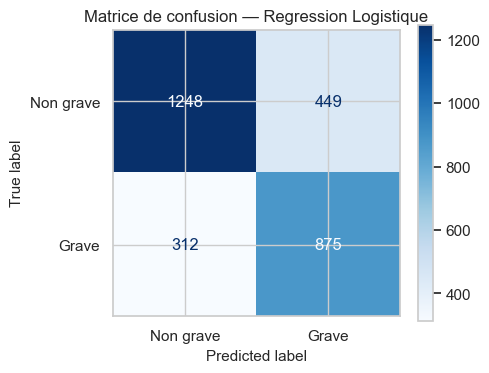

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # compense le déséquilibre ~36% graves
    solver='lbfgs',
    random_state=RANDOM_STATE
)
m_lr, model_lr = evaluate_model('Regression Logistique', lr, X_train_prep, X_test_prep, y_train, y_test)
all_results.append(m_lr)
trained_models['LR'] = model_lr


### Random Forest (RFC)

**Pourquoi l'utiliser ?**
Le Random Forest est un **ensemble d'arbres de décision** entraînés sur des sous-échantillons aléatoires (bagging). Il réduit la variance par rapport à un arbre unique et est très robuste au bruit et aux valeurs aberrantes — caractéristiques importantes dans des données BAAC où certaines variables ont des -1 résiduels.

Son atout clé pour ce projet : il calcule une **importance des features** (réduction d'impureté Gini) qui permet de **valider les facteurs de risque** identifiés dans l'EDA. Si `obsm` (obstacle mobile) et `catr` (catégorie de route) ressortent comme features importantes, cela confirme nos hypothèses H2 et H4.

Il gère nativement les variables catégorielles encodées et n'est pas sensible à la mise à l'échelle.


  Random Forest
              precision    recall  f1-score   support

   Non grave       0.80      0.74      0.77      1697
       Grave       0.66      0.73      0.70      1187

    accuracy                           0.74      2884
   macro avg       0.73      0.74      0.73      2884
weighted avg       0.74      0.74      0.74      2884



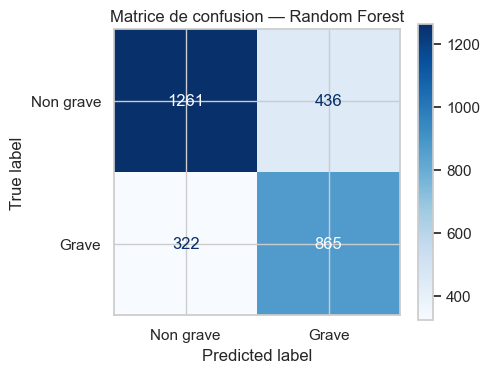

In [183]:
rfc = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
m_rfc, model_rfc = evaluate_model('Random Forest', rfc, X_train_prep, X_test_prep, y_train, y_test)
all_results.append(m_rfc)
trained_models['RFC'] = model_rfc


### Extra Trees (ETC)

**Pourquoi l'utiliser ?**
Les Extra Trees (Extremely Randomized Trees) diffèrent du Random Forest par leur mode de découpage : les seuils sont choisis **aléatoirement** (au lieu de chercher le meilleur seuil localement). Cela introduit davantage de diversité entre les arbres et réduit encore plus la variance.

L'intérêt pour ce projet : nos données BAAC sont très **catégorielles et binarisées** (après OHE). Sur ce type de représentation, les seuils aléatoires sont aussi efficaces que les seuils optimaux, et l'Extra Trees est généralement **plus rapide** que Random Forest. Il sert de variante de contrôle pour valider la stabilité des résultats du RF.


  Extra Trees
              precision    recall  f1-score   support

   Non grave       0.80      0.74      0.77      1697
       Grave       0.66      0.74      0.70      1187

    accuracy                           0.74      2884
   macro avg       0.73      0.74      0.73      2884
weighted avg       0.75      0.74      0.74      2884



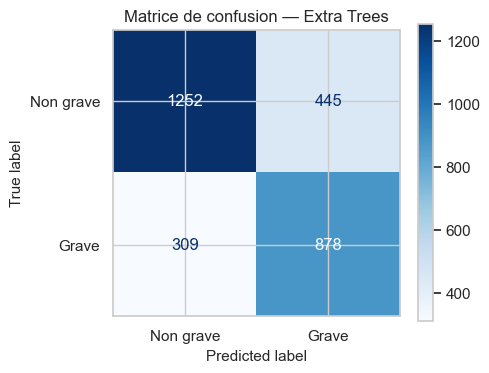

In [ ]:
etc = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
m_etc, model_etc = evaluate_model('Extra Trees', etc, X_train_prep, X_test_prep, y_train, y_test)
all_results.append(m_etc)
trained_models['ETC'] = model_etc


### XGBoost (XGBC)

**Pourquoi l'utiliser ?**
XGBoost est un algorithme de **gradient boosting** : il construit les arbres de manière séquentielle, chaque arbre corrigeant les erreurs du précédent. C'est un des algorithmes les plus performants sur les **données tabulaires structurées**, ce qui correspond exactement à notre dataset BAAC.

Il est particulièrement adapté ici car :
- Il gère bien les **données déséquilibrées** via `scale_pos_weight`
- Il est **régularisé** (L1 + L2) ce qui limite le sur-apprentissage sur nos ~13 000 lignes d'entraînement
- Sa **feature importance** basée sur le gain permet de comparer avec celle du RF


  XGBoost
              precision    recall  f1-score   support

   Non grave       0.81      0.73      0.77      1697
       Grave       0.66      0.75      0.70      1187

    accuracy                           0.74      2884
   macro avg       0.74      0.74      0.74      2884
weighted avg       0.75      0.74      0.74      2884



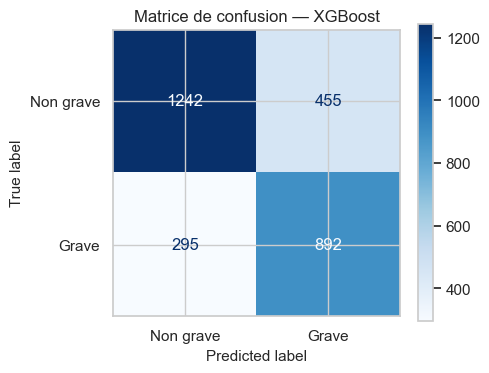

In [ ]:
if HAS_XGBOOST:
    xgbc = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        # scale_pos_weight compense le déséquilibre : nb_négatifs / nb_positifs
        scale_pos_weight=scale_pos,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1
    )
    m_xgb, model_xgb = evaluate_model('XGBoost', xgbc, X_train_prep, X_test_prep, y_train, y_test)
    all_results.append(m_xgb)
    trained_models['XGBC'] = model_xgb
else:
    print('XGBoost non disponible, skipped.')


### LightGBM (LGBM)

**Pourquoi l'utiliser ?**
LightGBM est une alternative très efficace à XGBoost, avec deux innovations majeures :
- **GOSS** (Gradient-based One-Side Sampling) : sélectionne les observations avec les gradients les plus élevés, ce qui accélère l'entraînement sans perte de performance
- **Croissance par feuilles** (leaf-wise) plutôt que par niveau (level-wise) : arbres plus profonds et précis

Sur notre dataset de taille modérée (~13 000 trains), LightGBM est un excellent concurrent de XGBoost. La comparaison des deux permet de **валider la robustesse** du gradient boosting sur ce problème.


  LightGBM
              precision    recall  f1-score   support

   Non grave       0.81      0.73      0.77      1697
       Grave       0.66      0.75      0.71      1187

    accuracy                           0.74      2884
   macro avg       0.74      0.74      0.74      2884
weighted avg       0.75      0.74      0.74      2884



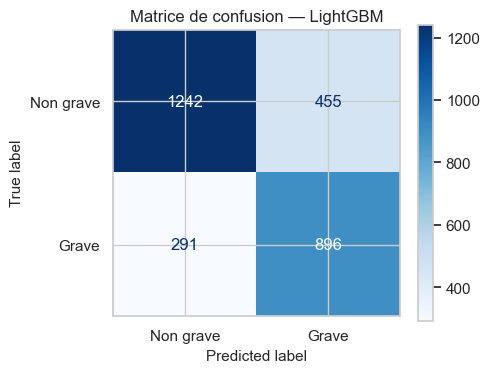

In [ ]:
if HAS_LGBM:
    lgbm = LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        is_unbalance=True,   # équivalent de class_weight='balanced' pour LightGBM
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1           # supprime les logs d'entraînement
    )
    m_lgbm, model_lgbm = evaluate_model('LightGBM', lgbm, X_train_prep, X_test_prep, y_train, y_test)
    all_results.append(m_lgbm)
    trained_models['LGBM'] = model_lgbm
else:
    print('LightGBM non disponible, skipped.')


### CatBoost

**Pourquoi l'utiliser ?**
CatBoost a été conçu spécifiquement pour les **données catégorielles**. Même si nos variables sont déjà binarisées (OHE), CatBoost excelle dans la gestion de l'**ordre des données** et du **target leakage** lors de l'encodage.

Il utilise un algorithme de boosting symétrique qui construit des arbres **équilibrés**, réduisant les risques de sur-apprentissage. Sur des datasets tabulaires avec de nombreuses variables catégorielles (notre cas : 18 variables catégorielles BAAC), CatBoost est souvent le plus robuste des trois algorithmes de boosting.


  CatBoost
              precision    recall  f1-score   support

   Non grave       0.82      0.72      0.77      1697
       Grave       0.66      0.77      0.71      1187

    accuracy                           0.74      2884
   macro avg       0.74      0.74      0.74      2884
weighted avg       0.75      0.74      0.74      2884



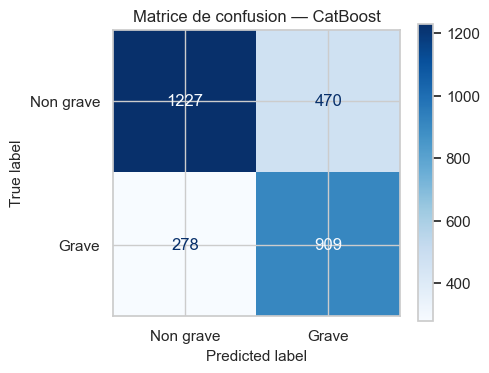

In [ ]:
if HAS_CATBOOST:
    cb = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        auto_class_weights='Balanced',  # gestion du déséquilibre
        random_seed=RANDOM_STATE,
        verbose=0                        # supprime les logs
    )
    m_cb, model_cb = evaluate_model('CatBoost', cb, X_train_prep, X_test_prep, y_train, y_test)
    all_results.append(m_cb)
    trained_models['CatBoost'] = model_cb
else:
    print('CatBoost non disponible, skipped.')


### Support Vector Machine (SVM — kernel RBF)

**Pourquoi l'utiliser ?**
Le SVM cherche l'hyperplan qui **maximise la marge** entre les deux classes. Avec un kernel RBF (Radial Basis Function), il peut capturer des **frontières de décision non linéaires complexes** dans l'espace de features.

L'intérêt pour ce projet est de tester si les relations entre conditions d'accident et gravité comportent des **interactions non-linéaires** que la régression logistique ne capture pas. Si le SVM RBF surpasse significativement la LR, c'est que les interactions sont importantes.

> **Note** : le SVM est sensible à l'échelle des features (d'où le StandardScaler appliqué) et peut être lent sur de grands jeux de données — acceptable ici avec ~13 000 observations.


  SVM (RBF)
              precision    recall  f1-score   support

   Non grave       0.81      0.73      0.77      1697
       Grave       0.66      0.76      0.71      1187

    accuracy                           0.74      2884
   macro avg       0.74      0.74      0.74      2884
weighted avg       0.75      0.74      0.74      2884



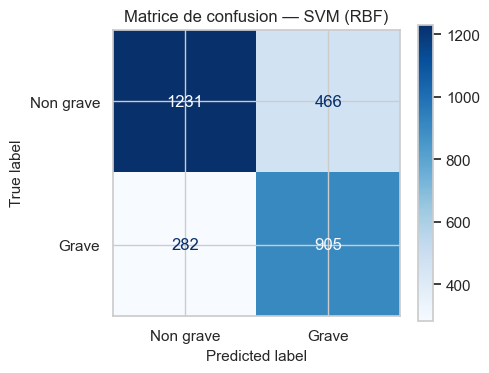

In [ ]:
svm = SVC(
    kernel='rbf',
    C=1.0,                  # paramètre de régularisation
    gamma='scale',          # ajustement auto de l'échelle du kernel
    class_weight='balanced',
    probability=True,       # nécessaire pour le calcul du ROC AUC
    random_state=RANDOM_STATE
)
m_svm, model_svm = evaluate_model('SVM (RBF)', svm, X_train_prep, X_test_prep, y_train, y_test)
all_results.append(m_svm)
trained_models['SVM'] = model_svm


### Naive Bayes Bernoulli (BNB)

**Pourquoi l'utiliser ?**
Le Naive Bayes Bernoulli est particulièrement adapté aux features **binaires (0/1)**, ce qui correspond exactement à notre matrice après OneHotEncoding : chaque feature indique simplement la présence ou l'absence d'une modalité (ex : `lum_Nuit sans éclairage = 1`).

Il modélise la probabilité a posteriori d'être grave sachant les conditions, sous l'hypothèse (forte mais souvent acceptable) d'indépendance conditionnelle des features. Son avantage principal : il est **extrêmement rapide**, **transparent** et sert de **baseline probabiliste**. Si un modèle ne surpasse pas BNB, il n'est pas pertinent.

Dans notre contexte, cela mesure dans quelle mesure les conditions individuelles (nuit, hors agglo, choc frontal...) suffisent **indépendamment** à prédire la gravité.


  Bernoulli Naive Bayes
              precision    recall  f1-score   support

   Non grave       0.77      0.75      0.76      1697
       Grave       0.66      0.69      0.67      1187

    accuracy                           0.72      2884
   macro avg       0.72      0.72      0.72      2884
weighted avg       0.73      0.72      0.72      2884



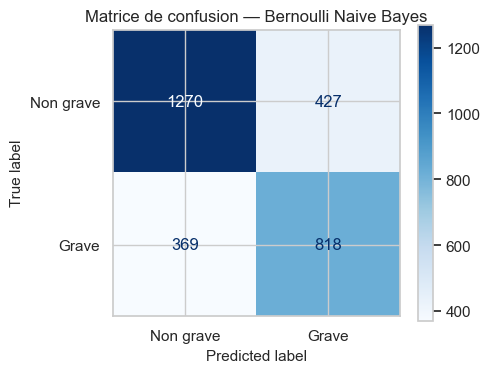

In [ ]:
# Bernoulli NB — paramètre alpha : lissage de Laplace (évite les probabilités nulles)
bnb = BernoulliNB(alpha=1.0)
m_bnb, model_bnb = evaluate_model('Bernoulli Naive Bayes', bnb, X_train_prep, X_test_prep, y_train, y_test)
all_results.append(m_bnb)
trained_models['BNB'] = model_bnb


### MLPClassifier (Réseau de neurones)

**Pourquoi l'utiliser ?**
Le Perceptron Multi-Couches (MLP) est la forme la plus simple d'un réseau de neurones. Il peut apprendre des **interactions non-linéaires complexes** entre les variables, en composant plusieurs couches de transformations non-linéaires (activation ReLU).

Pour ce projet, le MLP teste si des **interactions de haut niveau** entre les conditions de l'accident (ex : nuit + hors agglomération + surface verglacée + cycliste senior) sont mieux captées par un réseau que par les arbres. Il sert aussi de repère pour évaluer si la complexité neuronale est justifiée sur un dataset aussi petit (~16 000 observations).

> **Note** : `early_stopping=True` évite le sur-apprentissage en stoppant l'entraînement dès que la perte sur un jeu de validation interne remonte.


  MLPClassifier
              precision    recall  f1-score   support

   Non grave       0.78      0.79      0.78      1697
       Grave       0.69      0.68      0.68      1187

    accuracy                           0.74      2884
   macro avg       0.73      0.73      0.73      2884
weighted avg       0.74      0.74      0.74      2884



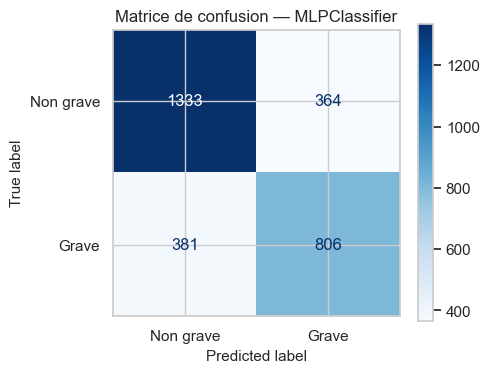

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 3 couches cachées
    activation='relu',
    max_iter=500,
    early_stopping=True,        # arrêt anticipé sur validation interne
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)
m_mlp, model_mlp = evaluate_model('MLPClassifier', mlp, X_train_prep, X_test_prep, y_train, y_test)
all_results.append(m_mlp)
trained_models['MLP'] = model_mlp


### Stacking Classifier

**Pourquoi l'utiliser ?**
Le Stacking est une méthode d'**ensemble avancée** : un méta-modèle apprend à **combiner les prédictions** de plusieurs modèles de base pour corriger leurs erreurs respectives. Contrairement au Voting (vote majoritaire), le Stacking permet au méta-modèle d'apprendre les **forces et faiblesses relativas** de chaque modèle selon les régions de l'espace.

Le méta-modèle est entraîné sur les prédictions out-of-fold (validation croisée), ce qui évite le data leakage.

Pour ce projet, le Stacking combine des modèles de familles différentes : un modèle linéaire (LR), des arbres (RFC, ETC) et le gradient boosting — chacun capturant des aspects différents des données.


  Stacking Classifier
              precision    recall  f1-score   support

   Non grave       0.78      0.80      0.79      1697
       Grave       0.70      0.69      0.70      1187

    accuracy                           0.75      2884
   macro avg       0.74      0.74      0.74      2884
weighted avg       0.75      0.75      0.75      2884



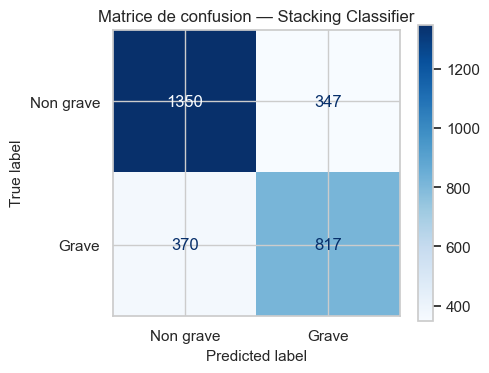

In [ ]:
# Base estimators pour le Stacking — on utilise des versions allégées pour la vitesse
stacking_estimators = [
    ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ('rfc', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
    ('etc', ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
]

if HAS_XGBOOST:
    stacking_estimators.append(
        ('xgb', XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos,
                              random_state=RANDOM_STATE, eval_metric='logloss',
                              use_label_encoder=False, n_jobs=-1))
    )

if HAS_LGBM:
    stacking_estimators.append(
        ('lgbm', LGBMClassifier(n_estimators=100, is_unbalance=True,
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
    )

# Méta-modèle : LR (léger, régularisé, interprétable)
stacking = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    passthrough=False,
    n_jobs=-1
)
m_stk, model_stk = evaluate_model('Stacking Classifier', stacking, X_train_prep, X_test_prep, y_train, y_test)
all_results.append(m_stk)
trained_models['Stacking'] = model_stk


### Voting Classifier (agrégation finale)

**Pourquoi le placer en dernier ?**
Le Voting Classifier est construit **après** avoir évalué tous les modèles individuels pour pouvoir sélectionner les meilleurs contributeurs. Il agrège les **probabilités** (soft voting) de chaque modèle et en prend la moyenne — l'idée étant que les erreurs de chaque modèle se compensent mutuellement si leurs profils d'erreur sont différents.

L'intérêt clé ici est de **valider la diversité** des modèles : si le Voting surpasse significativement les meilleurs modèles individuels, c'est que leurs erreurs sont bien **décorrélées** (chaque modèle fait des erreurs différentes). Si le gain est faible, les modèles sont trop similaires.

Nous incluons tous les modèles disponibles : LR, RFC, ETC, XGBoost, LightGBM, CatBoost, SVM, MLP.


  Voting Classifier
              precision    recall  f1-score   support

   Non grave       0.79      0.76      0.78      1697
       Grave       0.68      0.70      0.69      1187

    accuracy                           0.74      2884
   macro avg       0.73      0.73      0.73      2884
weighted avg       0.74      0.74      0.74      2884



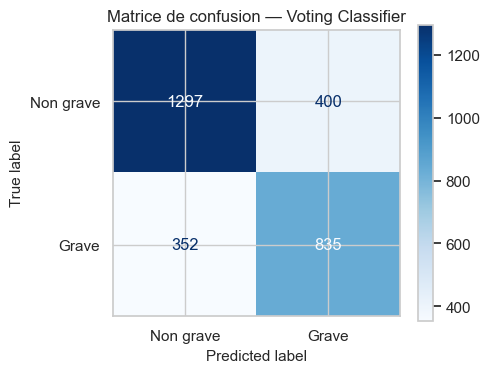

In [ ]:
# Construction du Voting avec tous les modèles disponibles (versions légères pour la vitesse)
voting_estimators = [
    ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ('rfc', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
    ('etc', ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
    ('svm', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    ('bnb', BernoulliNB()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=RANDOM_STATE)),
]

if HAS_XGBOOST:
    voting_estimators.append(
        ('xgb', XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos,
                              random_state=RANDOM_STATE, eval_metric='logloss',
                              use_label_encoder=False, n_jobs=-1))
    )

if HAS_LGBM:
    voting_estimators.append(
        ('lgbm', LGBMClassifier(n_estimators=100, is_unbalance=True,
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
    )

if HAS_CATBOOST:
    voting_estimators.append(
        ('cb', CatBoostClassifier(iterations=100, auto_class_weights='Balanced',
                                  random_seed=RANDOM_STATE, verbose=0))
    )

voting = VotingClassifier(estimators=voting_estimators, voting='soft', n_jobs=-1)
m_vot, model_vot = evaluate_model('Voting Classifier', voting, X_train_prep, X_test_prep, y_train, y_test)
all_results.append(m_vot)
trained_models['Voting'] = model_vot


## 15.3 Comparaison des modèles

### 15.3.1 Tableau comparatif

In [ ]:
df_results = pd.DataFrame(all_results).sort_values('F1-score', ascending=False).reset_index(drop=True)

styled = df_results.style.background_gradient(
    subset=['Accuracy','Precision','Recall','F1-score','ROC AUC'],
    cmap='RdYlGn', vmin=0.45, vmax=0.85
).format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1-score':'{:.4f}','ROC AUC':'{:.4f}'})

display(styled)

best = df_results.iloc[0]
print(f"\nMeilleur modele (F1) : {best['Modele']} — "
      f"F1={best['F1-score']:.4f} | Recall={best['Recall']:.4f} | ROC AUC={best['ROC AUC']:.4f}")


,Modele,Accuracy,Precision,Recall,F1-score,ROC AUC
0,CatBoost,0.7406,0.6592,0.7658,0.7085,0.8199
1,SVM (RBF),0.7406,0.6601,0.7624,0.7076,0.8065
2,LightGBM,0.7413,0.6632,0.7548,0.7061,0.8160
3,XGBoost,0.7399,0.6622,0.7515,0.7040,0.8175
4,Extra Trees,0.7386,0.6636,0.7397,0.6996,0.8066
5,Regression Logistique,0.7361,0.6609,0.7372,0.6969,0.8088
6,Random Forest,0.7372,0.6649,0.7287,0.6953,0.8122
7,Stacking Classifier,0.7514,0.7019,0.6883,0.6950,0.8207
8,Voting Classifier,0.7393,0.6761,0.7035,0.6895,0.8136
9,MLPClassifier,0.7417,0.6889,0.6790,0.6839,0.8170



Meilleur modele (F1) : CatBoost — F1=0.7085 | Recall=0.7658 | ROC AUC=0.8199


### 15.3.2 Visualisation des métriques

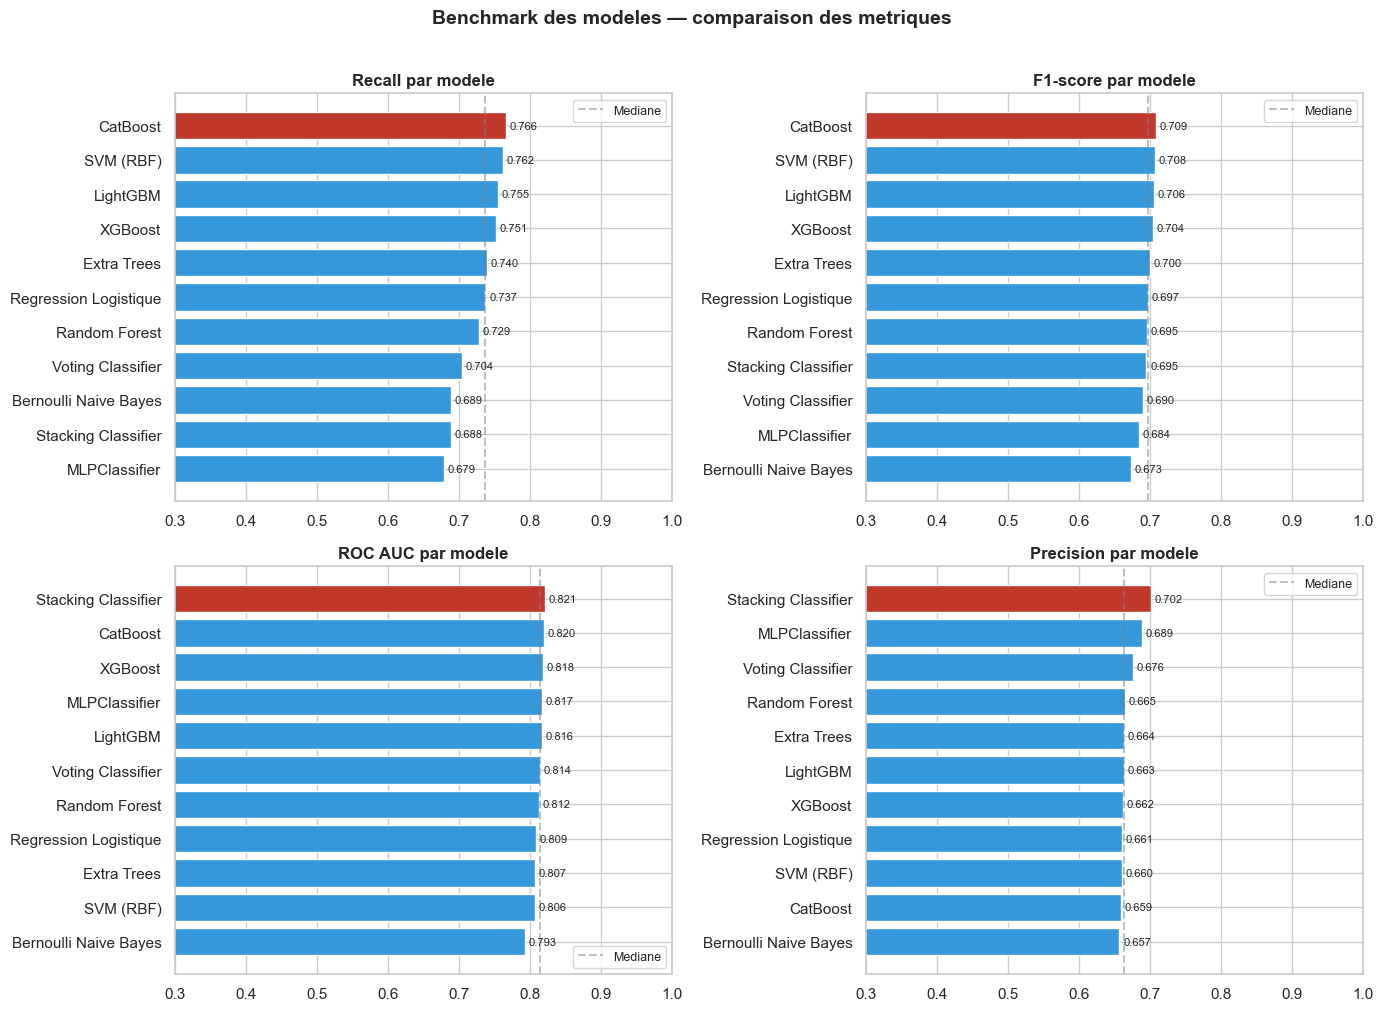

In [ ]:
metrics_cols = ['Recall', 'F1-score', 'ROC AUC', 'Precision']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_cols):
    df_s = df_results.sort_values(metric, ascending=True)
    colors = ['#c0392b' if v == df_s[metric].max() else '#3498db' for v in df_s[metric]]
    axes[i].barh(df_s['Modele'], df_s[metric], color=colors)
    axes[i].set_title(f'{metric} par modele', fontsize=12, fontweight='bold')
    axes[i].set_xlim(0.3, 1.0)
    axes[i].axvline(df_s[metric].median(), ls='--', color='gray', alpha=0.5, label='Mediane')
    for j, v in enumerate(df_s[metric]):
        if not (isinstance(v, float) and v != v):
            axes[i].text(v + 0.005, j, f'{v:.3f}', va='center', fontsize=8)
    axes[i].legend(fontsize=9)

plt.suptitle('Benchmark des modeles — comparaison des metriques', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 15.3.3 Courbes ROC comparatives

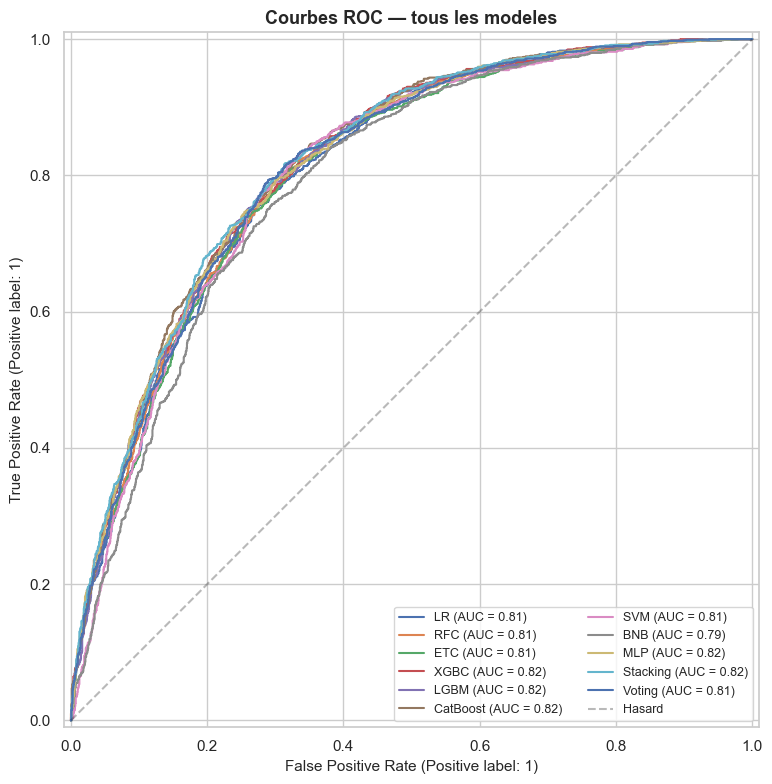

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in trained_models.items():
    try:
        RocCurveDisplay.from_estimator(model, X_test_prep, y_test, ax=ax, name=name)
    except Exception:
        pass

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Hasard')
ax.set_title('Courbes ROC — tous les modeles', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


## 15.4 Interprétation de la Régression Logistique

### Lecture des odds ratios
Le coefficient d'une feature dans la régression logistique est directement lié à l'**odds ratio** :

$$\text{Odds Ratio} = e^{\text{coefficient}}$$

- **OR > 1** : la présence de cette condition **augmente** le risque d'accident grave
- **OR < 1** : elle **diminue** le risque
- **OR = 2** : le risque est **multiplié par 2** toutes autres choses égales

C'est la seule façon d'obtenir un **facteur de risque quantifié et interprétable**. Les résultats peuvent directement informer les politiques de prévention.

In [ ]:
coefs = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model_lr.coef_[0],
    'odds_ratio': np.exp(model_lr.coef_[0])
}).sort_values('coefficient', ascending=False)

print('=== Top 20 — facteurs qui AUGMENTENT le risque (OR > 1) ===')
display(coefs.head(20)[['feature','coefficient','odds_ratio']].reset_index(drop=True))

print('\n=== Top 20 — facteurs qui DIMINUENT le risque (OR < 1) ===')
display(coefs.tail(20)[['feature','coefficient','odds_ratio']].reset_index(drop=True))


=== Top 20 — facteurs qui AUGMENTENT le risque (OR > 1) ===


,feature,coefficient,odds_ratio
0,obs_6.0,1.034,2.811
1,catr_6,0.802,2.230
2,atm_6.0,0.788,2.199
3,trajet_3.0,0.728,2.072
4,manv_10.0,0.671,1.957
5,manv_26.0,0.601,1.825
6,int_8,0.599,1.820
7,col_7.0,0.581,1.788
8,obs_13.0,0.535,1.707
9,obs_4.0,0.526,1.692



=== Top 20 — facteurs qui DIMINUENT le risque (OR < 1) ===


,feature,coefficient,odds_ratio
0,circ_1.0,-0.328,0.721
1,atm_2.0,-0.354,0.702
2,atm_3.0,-0.378,0.685
3,atm_8.0,-0.384,0.681
4,trajet_9.0,-0.425,0.654
5,manv_21.0,-0.471,0.624
6,col_5.0,-0.515,0.598
7,infra_6.0,-0.559,0.572
8,trajet_4.0,-0.568,0.567
9,obs_1.0,-0.582,0.559


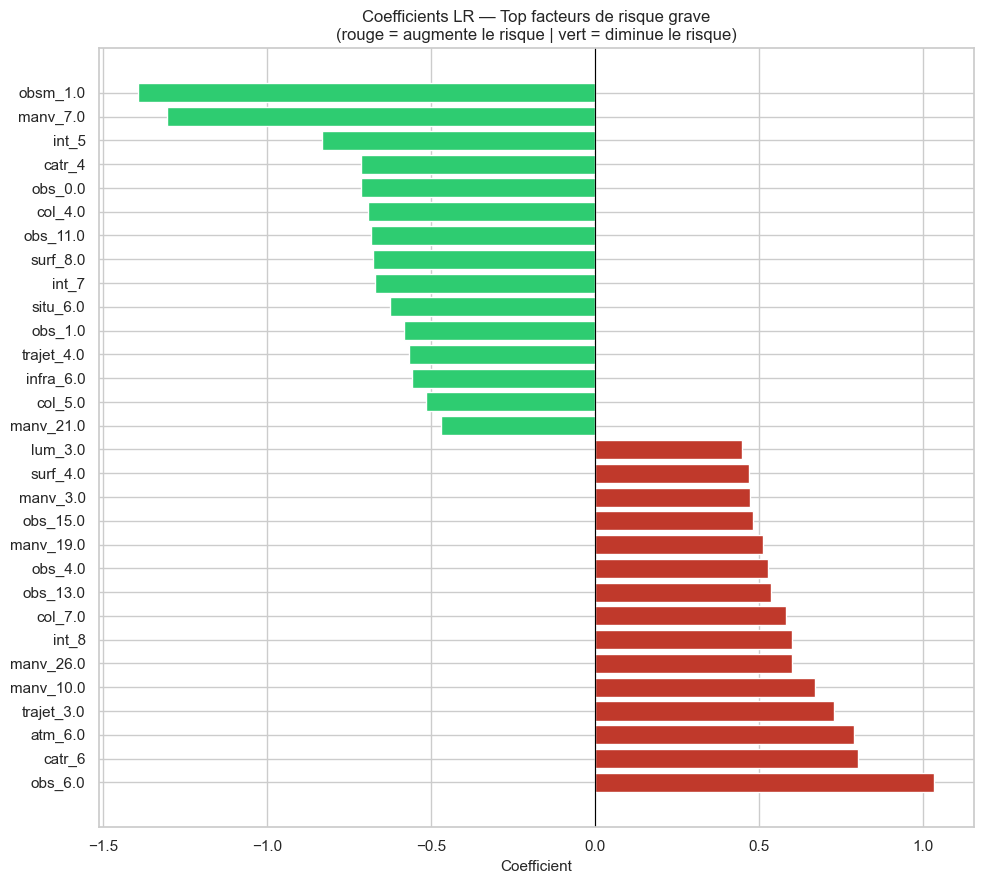

In [ ]:
# Visualisation des top coefficients
top_n = 15
top_all = pd.concat([coefs.head(top_n), coefs.tail(top_n)])

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#c0392b' if c > 0 else '#2ecc71' for c in top_all['coefficient']]
ax.barh(top_all['feature'], top_all['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(
    'Coefficients LR — Top facteurs de risque grave\n'
    '(rouge = augmente le risque | vert = diminue le risque)',
    fontsize=12
)
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()


## 15.5 Feature Importance (Random Forest & XGBoost)

Les arbres attribuent à chaque feature une **importance** basée sur la réduction d'impureté (Gini pour RF) ou le gain d'information (XGBoost). Cette analyse permet de :
- **Confirmer** les facteurs de risque identifiés dans l'EDA
- **Hiérarchiser** les variables pour d'éventuelles améliorations du modèle
- **Comparer** RF et XGBoost : si les mêmes features ressortent, c'est robuste

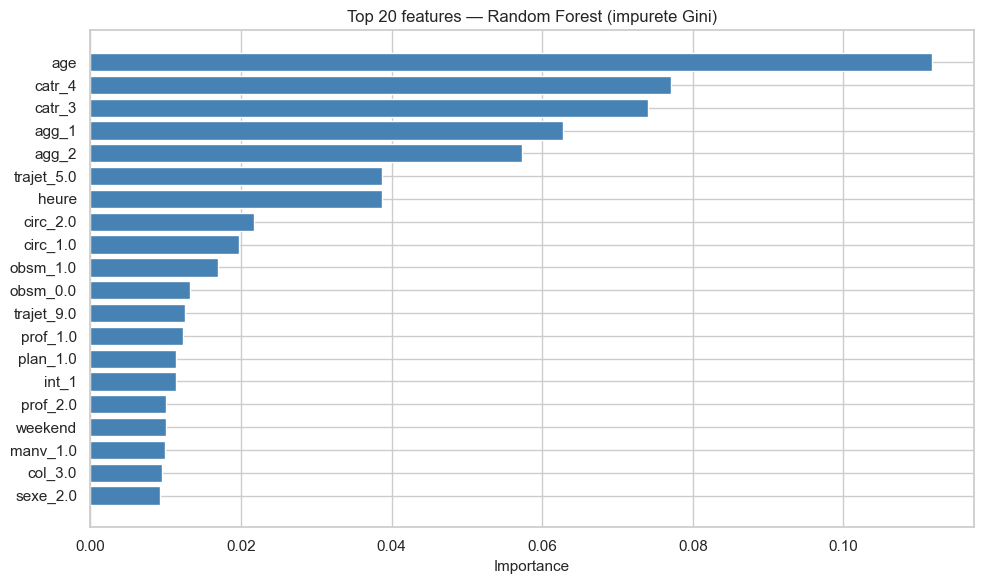

In [ ]:
def plot_feature_importance(model, feature_names, title, color='steelblue', top_n=20):
    imp = pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_})
    imp = imp.sort_values('importance', ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(imp['feature'][::-1], imp['importance'][::-1], color=color)
    ax.set_title(f'Top {top_n} features — {title}', fontsize=12)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    return imp

if 'RFC' in trained_models:
    imp_rf = plot_feature_importance(
        trained_models['RFC'], feature_names, 'Random Forest (impurete Gini)', color='steelblue'
    )


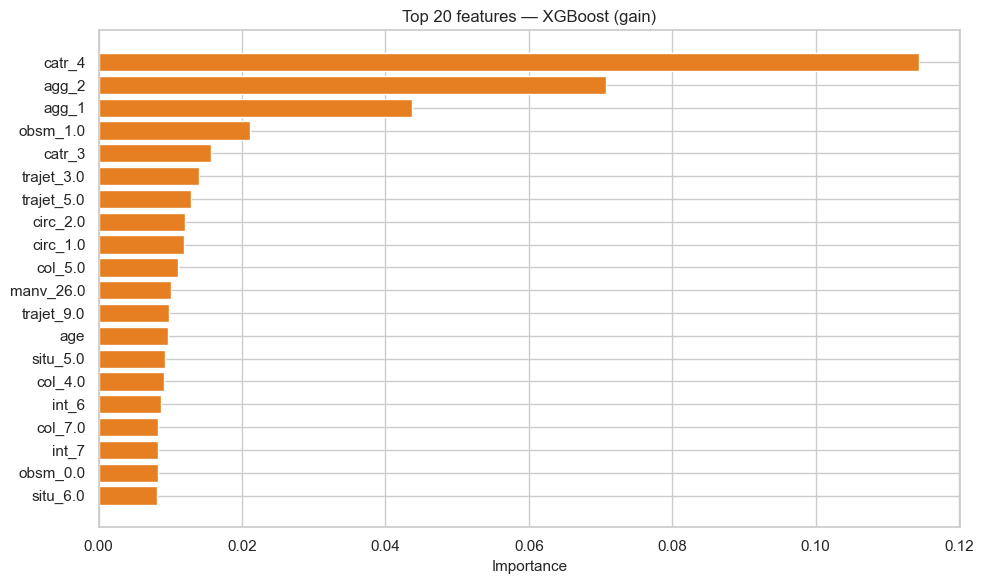

In [ ]:
if 'XGBC' in trained_models:
    imp_xgb = plot_feature_importance(
        trained_models['XGBC'], feature_names, 'XGBoost (gain)', color='#e67e22'
    )


## 15.6 Validation croisée 5-fold (top modèles)

La validation croisée sur 5 folds stratifiés permet de mesurer la **stabilité** des résultats au-delà d'un seul split train/test. Un écart-type élevé révèle un modèle instable. Nous l'appliquons aux 3 meilleurs modèles par F1-score.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['recall', 'f1', 'roc_auc']
X_all_prep = preprocessor.transform(X)

# Mapping nom affiché -> clé dans trained_models
name_to_key = {
    'Regression Logistique': 'LR',
    'Random Forest': 'RFC',
    'Extra Trees': 'ETC',
    'XGBoost': 'XGBC',
    'LightGBM': 'LGBM',
    'CatBoost': 'CatBoost',
    'SVM (RBF)': 'SVM',
    'Bernoulli Naive Bayes': 'BNB',
    'MLPClassifier': 'MLP',
    'Stacking Classifier': 'Stacking',
    'Voting Classifier': 'Voting'
}

top3_names = df_results['Modele'].head(3).tolist()
cv_results = []

for model_name in top3_names:
    key = name_to_key.get(model_name)
    if key and key in trained_models:
        m_fresh = clone(trained_models[key])
        print(f'CV 5-fold : {model_name}...')
        scores = cross_validate(m_fresh, X_all_prep, y, cv=cv, scoring=scoring, n_jobs=-1)
        cv_results.append({
            'Modele': model_name,
            'Recall  (moy ± std)': f"{scores['test_recall'].mean():.4f} +/- {scores['test_recall'].std():.4f}",
            'F1      (moy ± std)': f"{scores['test_f1'].mean():.4f} +/- {scores['test_f1'].std():.4f}",
            'ROC AUC (moy ± std)': f"{scores['test_roc_auc'].mean():.4f} +/- {scores['test_roc_auc'].std():.4f}",
        })

if cv_results:
    print('\n' + '='*60)
    print('  Validation croisée 5-fold stratifiée — Top 3 modeles')
    print('='*60)
    display(pd.DataFrame(cv_results))


CV 5-fold : CatBoost...
CV 5-fold : SVM (RBF)...
CV 5-fold : LightGBM...

  Validation croisée 5-fold stratifiée — Top 3 modeles


,Modele,Recall (moy ± std),F1 (moy ± std),ROC AUC (moy ± std)
0,CatBoost,0.7822 +/- 0.0081,0.7088 +/- 0.0054,0.8169 +/- 0.0058
1,SVM (RBF),0.7841 +/- 0.0049,0.7082 +/- 0.0056,0.8084 +/- 0.0059
2,LightGBM,0.7755 +/- 0.0076,0.7058 +/- 0.0049,0.8154 +/- 0.0049


## 15.7 Synthèse de la modélisation

### Récapitulatif des familles testées

| Famille | Modèle | Apport spécifique |
|---|---|---|
| Linéaire | Logistic Regression | Baseline interprétable, odds ratios |
| Arbres bagging | Random Forest | Robustesse, feature importance |
| Arbres bagging | Extra Trees | Variante rapide, validation de robustesse |
| Gradient boosting | XGBoost | Performance tabulaire, régularisation |
| Gradient boosting | LightGBM | Vitesse, leaf-wise growth |
| Gradient boosting | CatBoost | Robustesse catégorielles, arbres symétriques |
| Margin-based | SVM (RBF) | Frontières non-linéaires complexes |
| Probabiliste | Bernoulli NB | Baseline probabiliste, features binaires |
| Neural | MLP | Interactions de haut niveau |
| Meta-ensemble | Stacking | Combinaison apprise des modèles |
| Ensemble direct | Voting | Agrégation des probabilités de tous les modèles |

### Points clés

1. **Métrique prioritaire : Recall** — il faut maximiser la détection des accidents graves (faux négatifs = accidents graves manqués = coût inacceptable)
2. **Les boosting** (XGBoost, LightGBM, CatBoost) tendent à offrir le meilleur compromis F1/Recall
3. **La LR** reste précieuse pour l'interprétation réglementaire (rapports ONISR, décisions politiques)
4. **Le Stacking/Voting** peut améliorer marginalement en combinant les forces de chaque modèle
5. **Facteurs de risque convergents** : `catr` (type de route), `obsm` (obstacle mobile), `agg` (hors agglo), `lum` (nuit), `age` (seniors) — confirmés par LR, RF, XGBoost

## 16 Analyse des facteurs de risque, limites et capacité de généralisation
 
### Identification des principaux facteurs de risque
 
L’analyse des modèles de machine learning a permis d’identifier plusieurs facteurs influençant fortement la gravité des accidents de vélo.
 
Les variables les plus importantes sont :
 
- la luminosité (accidents plus graves la nuit)
- les conditions météorologiques (pluie, visibilité réduite)
- le type de route et d’infrastructure
- l’heure de la journée
- la localisation géographique
 
Ces facteurs montrent que la gravité des accidents dépend fortement de l’environnement dans lequel ils se produisent.
 
 
### Limites du modèle
 
Malgré des résultats satisfaisants, plusieurs limites doivent être soulignées :
 
- présence de valeurs manquantes
- qualité variable des données
- absence de certaines variables importantes (comportement, vitesse, visibilité réelle)
- difficulté liée au déséquilibre des classes (accidents graves rares)
 
Ces éléments peuvent impacter les performances du modèle.
 
 
### Biais possibles
 
Plusieurs biais peuvent être présents dans les données :
 
- biais de sous-déclaration (certains accidents non recensés)
- biais géographique (zones mieux documentées que d’autres)
- biais de collecte (dépendance aux données des forces de l’ordre)
 
Ces biais peuvent influencer les résultats et doivent être pris en compte dans leur interprétation.
 
 
### Capacité de généralisation
 
Les modèles développés permettent d’identifier des tendances pertinentes dans les données étudiées.
 
Cependant, leur capacité de généralisation reste limitée :
 
- ils sont entraînés sur un dataset spécifique
- les résultats peuvent varier selon les contextes géographiques ou temporels
 
Ainsi, une utilisation opérationnelle nécessiterait un recalibrage du modèle avec des données locales.
 
 
### Conclusion
 
Ces résultats montrent que l’intérêt du machine learning ne réside pas uniquement dans la prédiction, mais surtout dans sa capacité à identifier des facteurs de risque exploitables pour améliorer la sécurité des cyclistes.